# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/model ml/anomaly fighting detection"

Mounted at /content/drive
/content/drive/MyDrive/model ml/anomaly fighting detection


# Import libraries

In [ ]:
!pip install ultralytics
!pip install -U ipywidgets
!pip install roboflow
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
import os
from roboflow import Roboflow
import glob
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Download the Data from Roboflow & Data Exploration

In [ ]:
rf = Roboflow(api_key="") #roboflow api
project = rf.workspace("securityviolence").project("violence-detection-p4qev")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


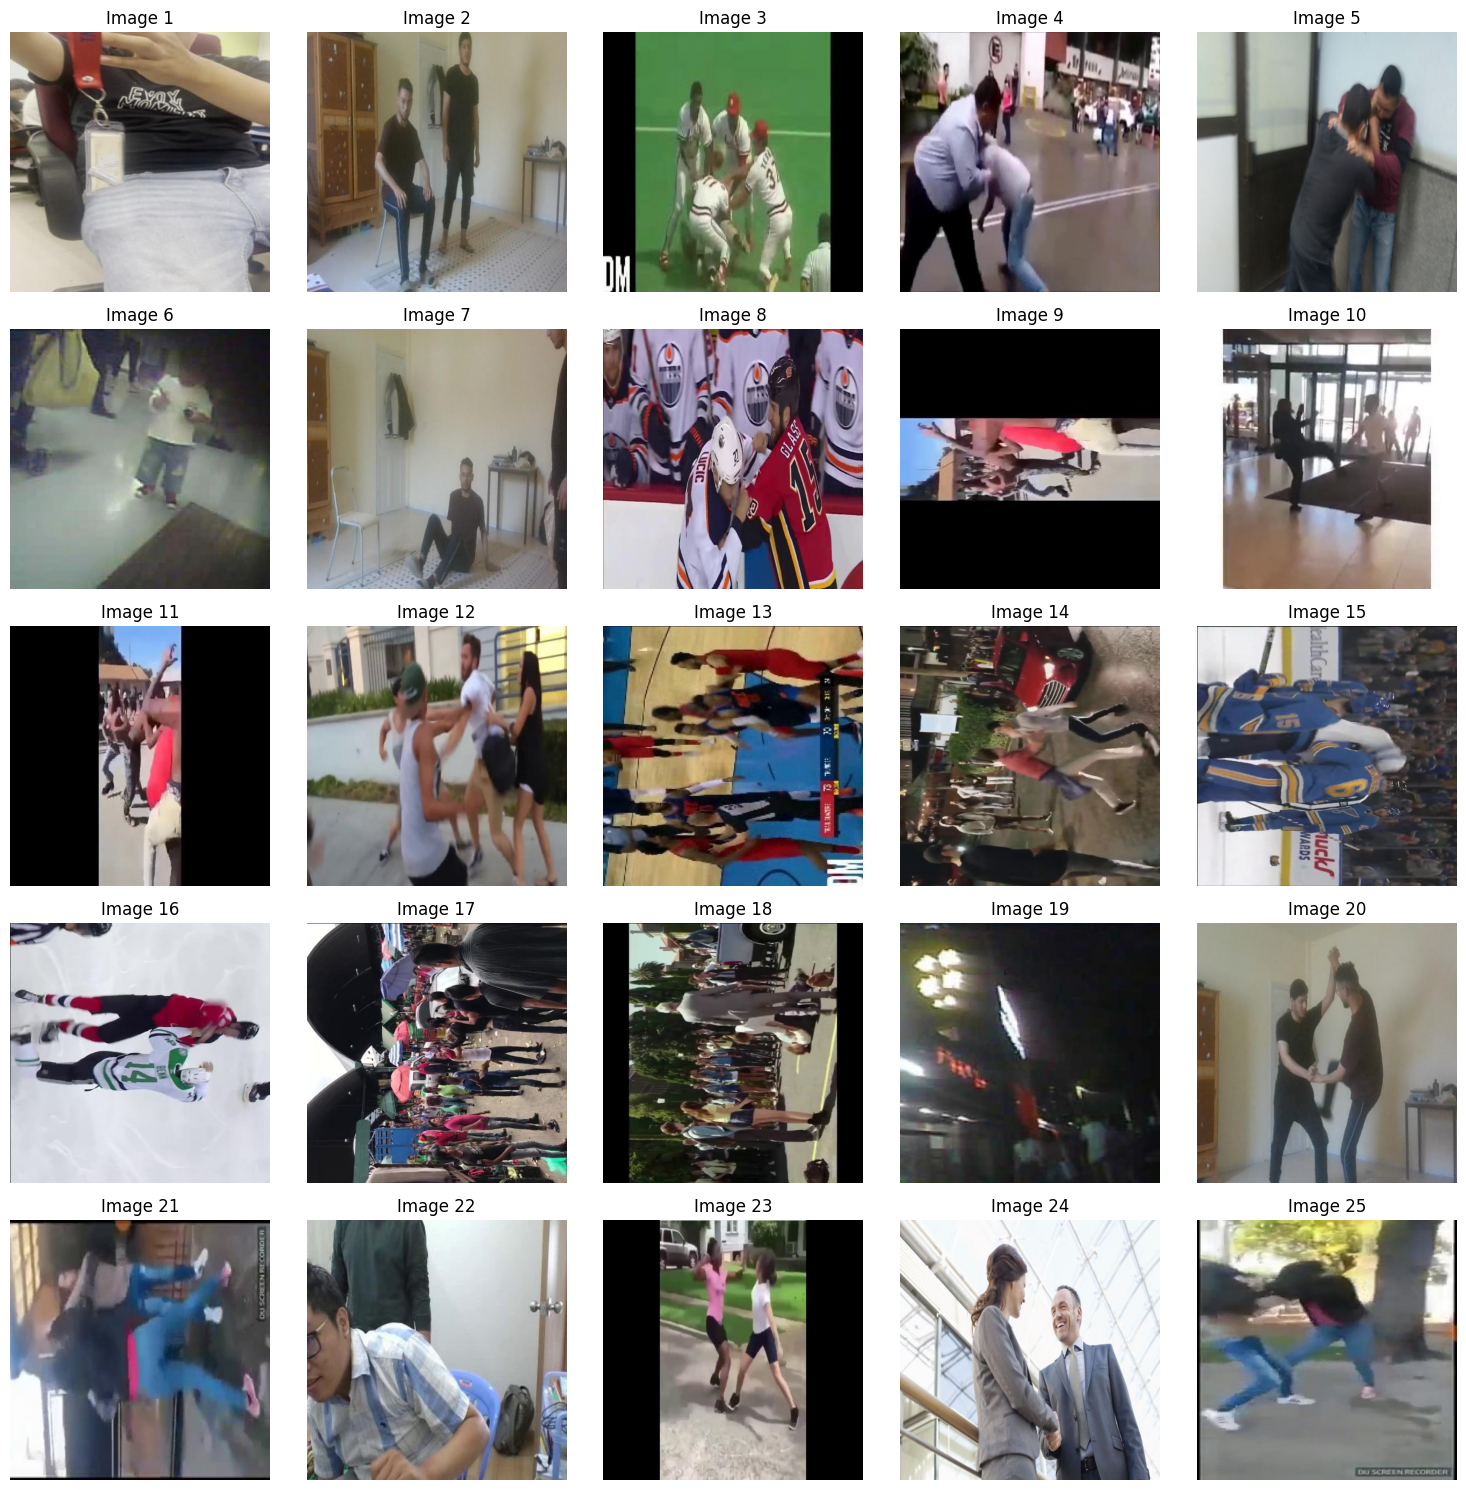

In [ ]:
image_paths = glob.glob("/content/violence-detection-4/train/images/*.jpg")

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()


for i, (img_path, ax) in enumerate(zip(image_paths[:25], axes)):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')  # Hide axes

    ax.set_title(f"Image {i + 1}", fontsize=12)

plt.tight_layout()
plt.show()

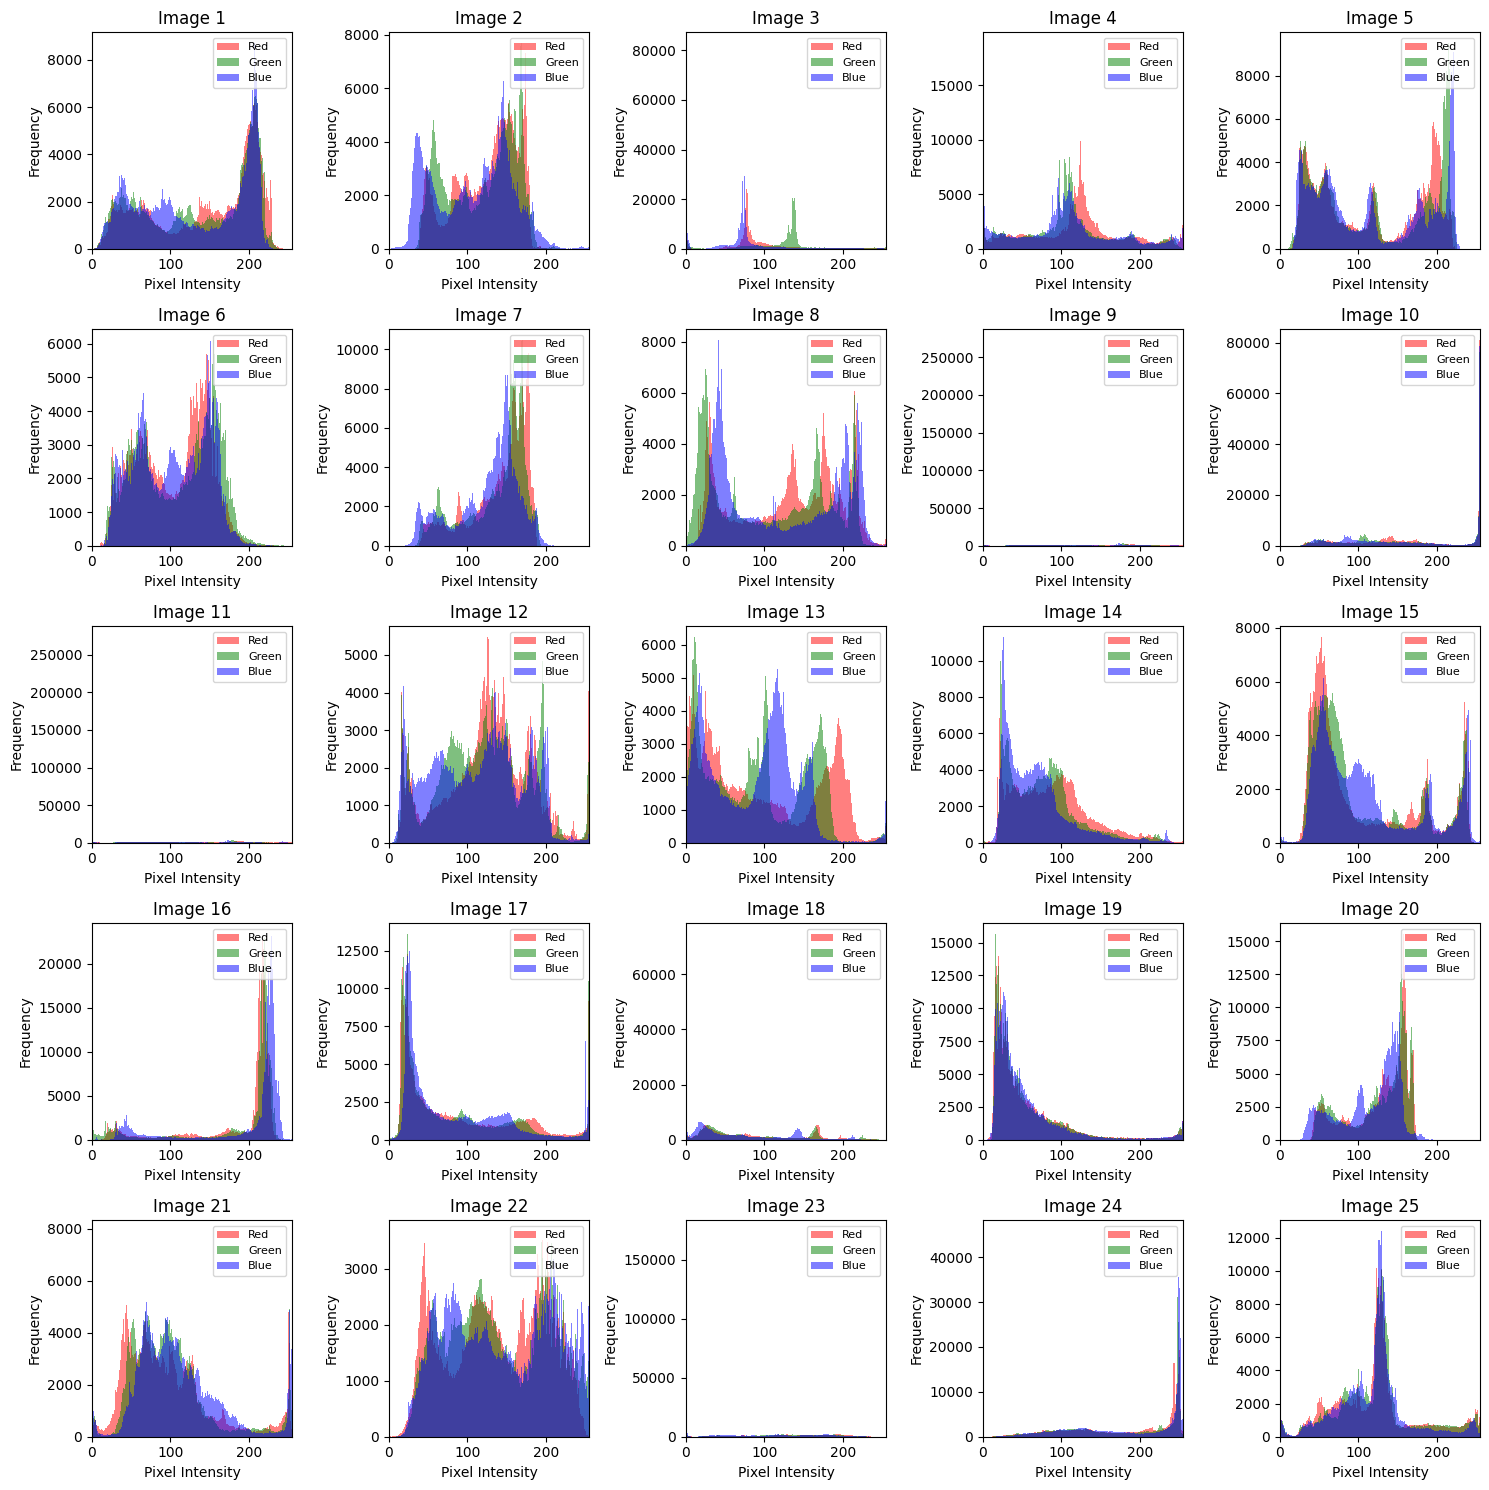

In [ ]:
#display the pixel distribution in RGB for each of the 25 images

# Load image paths
image_paths = glob.glob("/content/violence-detection-4/train/images/*.jpg")

# Create a figure with subplots
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
axes = axes.flatten()

# Loop through the first 25 images
for i, (img_path, ax) in enumerate(zip(image_paths[:25], axes)):
    # Open the image
    img = Image.open(img_path)
    img_array = np.array(img)

    # Check if the image is RGB
    if len(img_array.shape) == 3 and img_array.shape[2] == 3:  # Ensure it's an RGB image
        # Split the image into Red, Green, and Blue channels
        r_channel = img_array[:, :, 0].flatten()  # Red
        g_channel = img_array[:, :, 1].flatten()  # Green
        b_channel = img_array[:, :, 2].flatten()  # Blue

        # Plot histograms for each channel
        ax.hist(r_channel, bins=256, range=(0, 255), color='red', alpha=0.5, label='Red')
        ax.hist(g_channel, bins=256, range=(0, 255), color='green', alpha=0.5, label='Green')
        ax.hist(b_channel, bins=256, range=(0, 255), color='blue', alpha=0.5, label='Blue')

        # Add title and hide axes
        ax.set_title(f"Image {i + 1}", fontsize=12)
        ax.set_xlim(0, 255)
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')
        ax.legend(loc='upper right', fontsize=8)
    else:
        ax.set_title(f"Image {i + 1}: Not RGB", fontsize=12)

plt.tight_layout()
plt.show()

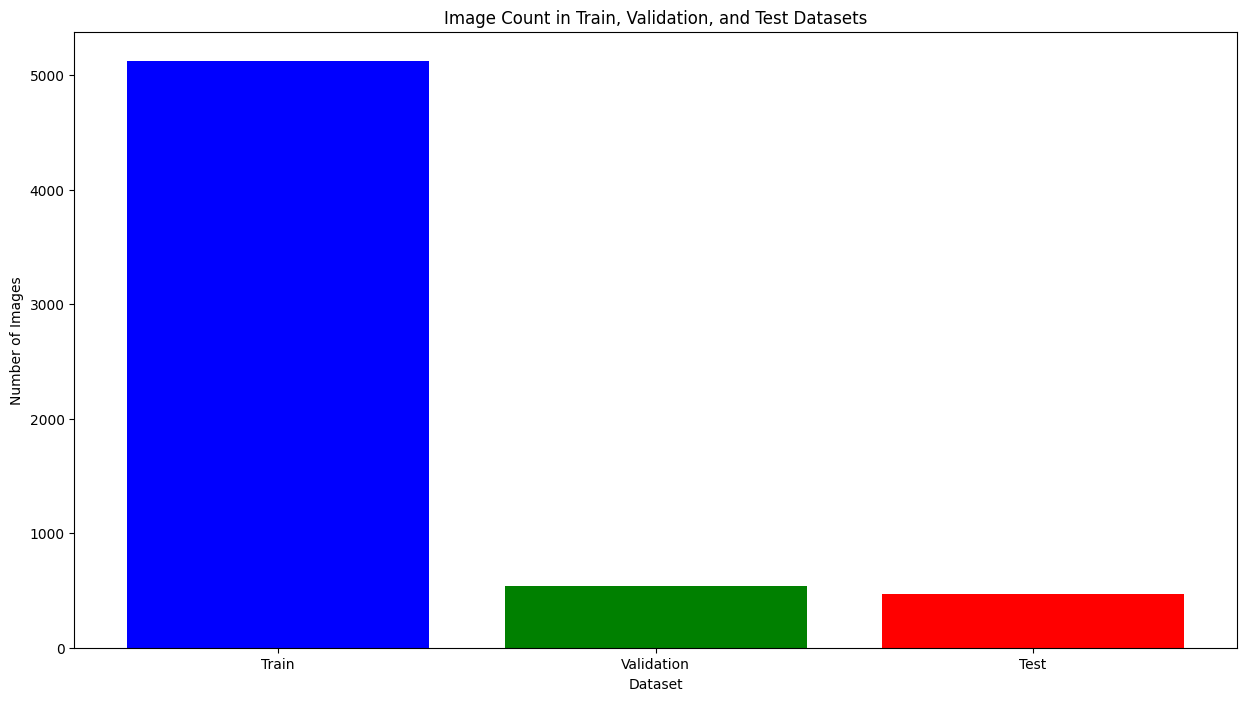

In [ ]:
# Paths to the image directories
train_path = '/content/violence-detection-4/train/images'
valid_path = '/content/violence-detection-4/valid/images'
test_path = '/content/violence-detection-4/test/images'

# Count the number of files in each directory
train_count = len(os.listdir(train_path))
valid_count = len(os.listdir(valid_path))
test_count = len(os.listdir(test_path))

# Create a dictionary to hold the counts
data_counts = {'Train': train_count, 'Validation': valid_count, 'Test': test_count}

# Create a count plot
plt.figure(figsize=(15, 8))
plt.bar(data_counts.keys(), data_counts.values(), color=['blue', 'green', 'red'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Image Count in Train, Validation, and Test Datasets')
plt.show()

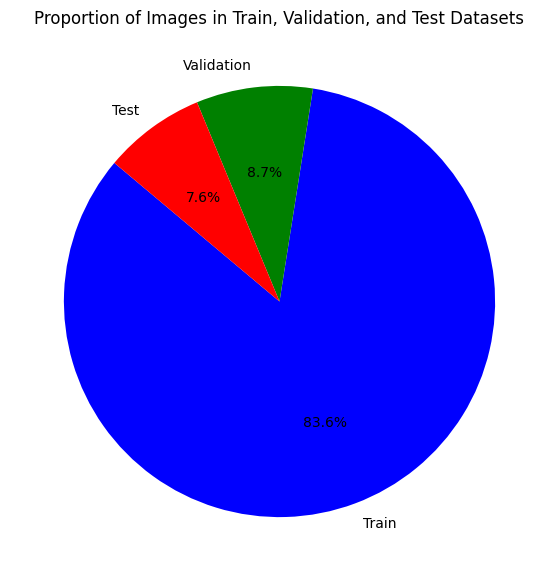

In [ ]:
# Count the number of files in each directory
train_count = len(os.listdir(train_path))
valid_count = len(os.listdir(valid_path))
test_count = len(os.listdir(test_path))

# Create a dictionary to hold the counts
data_counts = {'Train': train_count, 'Validation': valid_count, 'Test': test_count}

# Create a pie chart
plt.figure(figsize=(10, 7))
plt.pie(data_counts.values(), labels=data_counts.keys(), autopct='%1.1f%%', colors=['blue', 'green', 'red'], startangle=140)
plt.title('Proportion of Images in Train, Validation, and Test Datasets')
plt.show()

# Training

In [ ]:
%cd "/content/drive/MyDrive/model ml/anomaly fighting detection/FightingDetection1.4.0"
# Disable Weights & Biases if not needed
os.environ['WANDB_MODE'] = 'dryrun'


/content/drive/MyDrive/model ml/anomaly fighting detection/FightingDetection1.4.0


In [ ]:
model = YOLO('yolov8s.pt')
model.train(
    data='/content/drive/MyDrive/model ml/anomaly fighting detection/violence-detection-4/data.yaml',
    epochs=50,
    imgsz=640,
    optimizer="RAdam",
    batch=8,
    device=0,
    lr0=0.001,
    patience=10
)

Ultralytics 8.3.170 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/model ml/anomaly fighting detection/violence-detection-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=RAdam, overlap_mask=True, pati

train: Scanning /content/drive/MyDrive/model ml/anomaly fighting detection/violence-detection-4/train/labels.cache... 5123 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5123/5123 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 1.6±1.4 ms, read: 8.6±5.9 MB/s, size: 30.1 KB)


val: Scanning /content/drive/MyDrive/model ml/anomaly fighting detection/violence-detection-4/valid/labels.cache... 535 images, 0 backgrounds, 0 corrupt: 100%|██████████| 535/535 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: RAdam(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50      2.08G      1.399      1.895      1.559         40        640:  86%|████████▋ | 553/641 [02:03<00:19,  4.47it/s]


KeyboardInterrupt: 

# Training Results

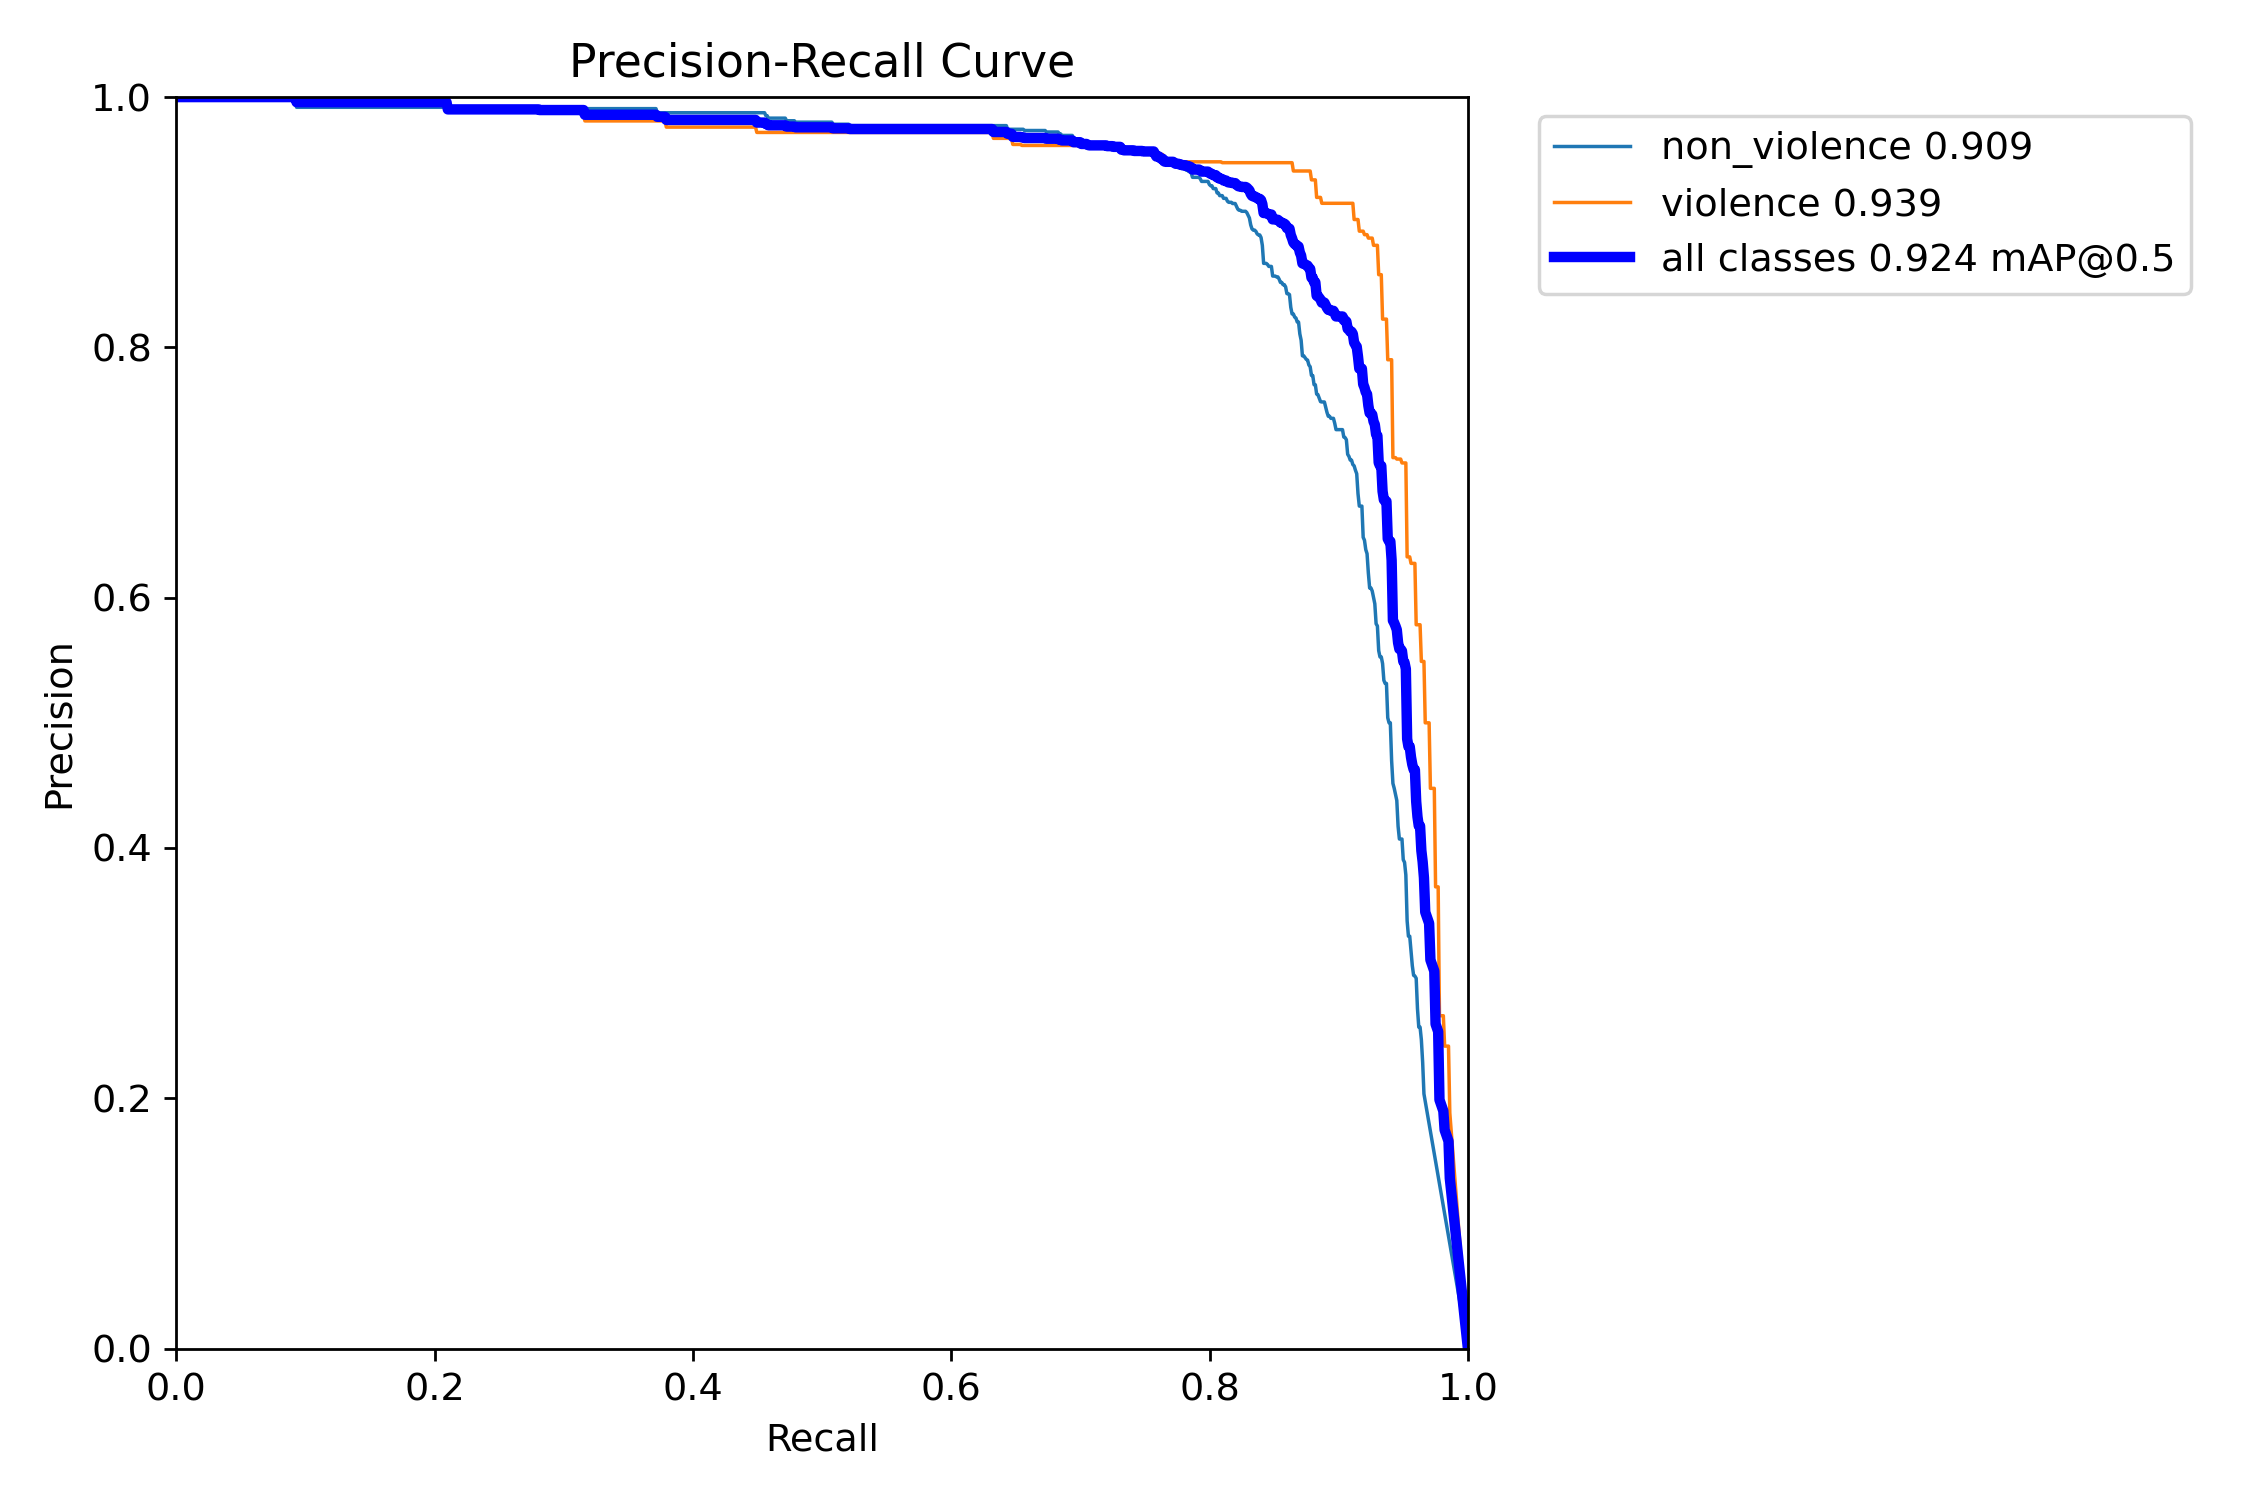

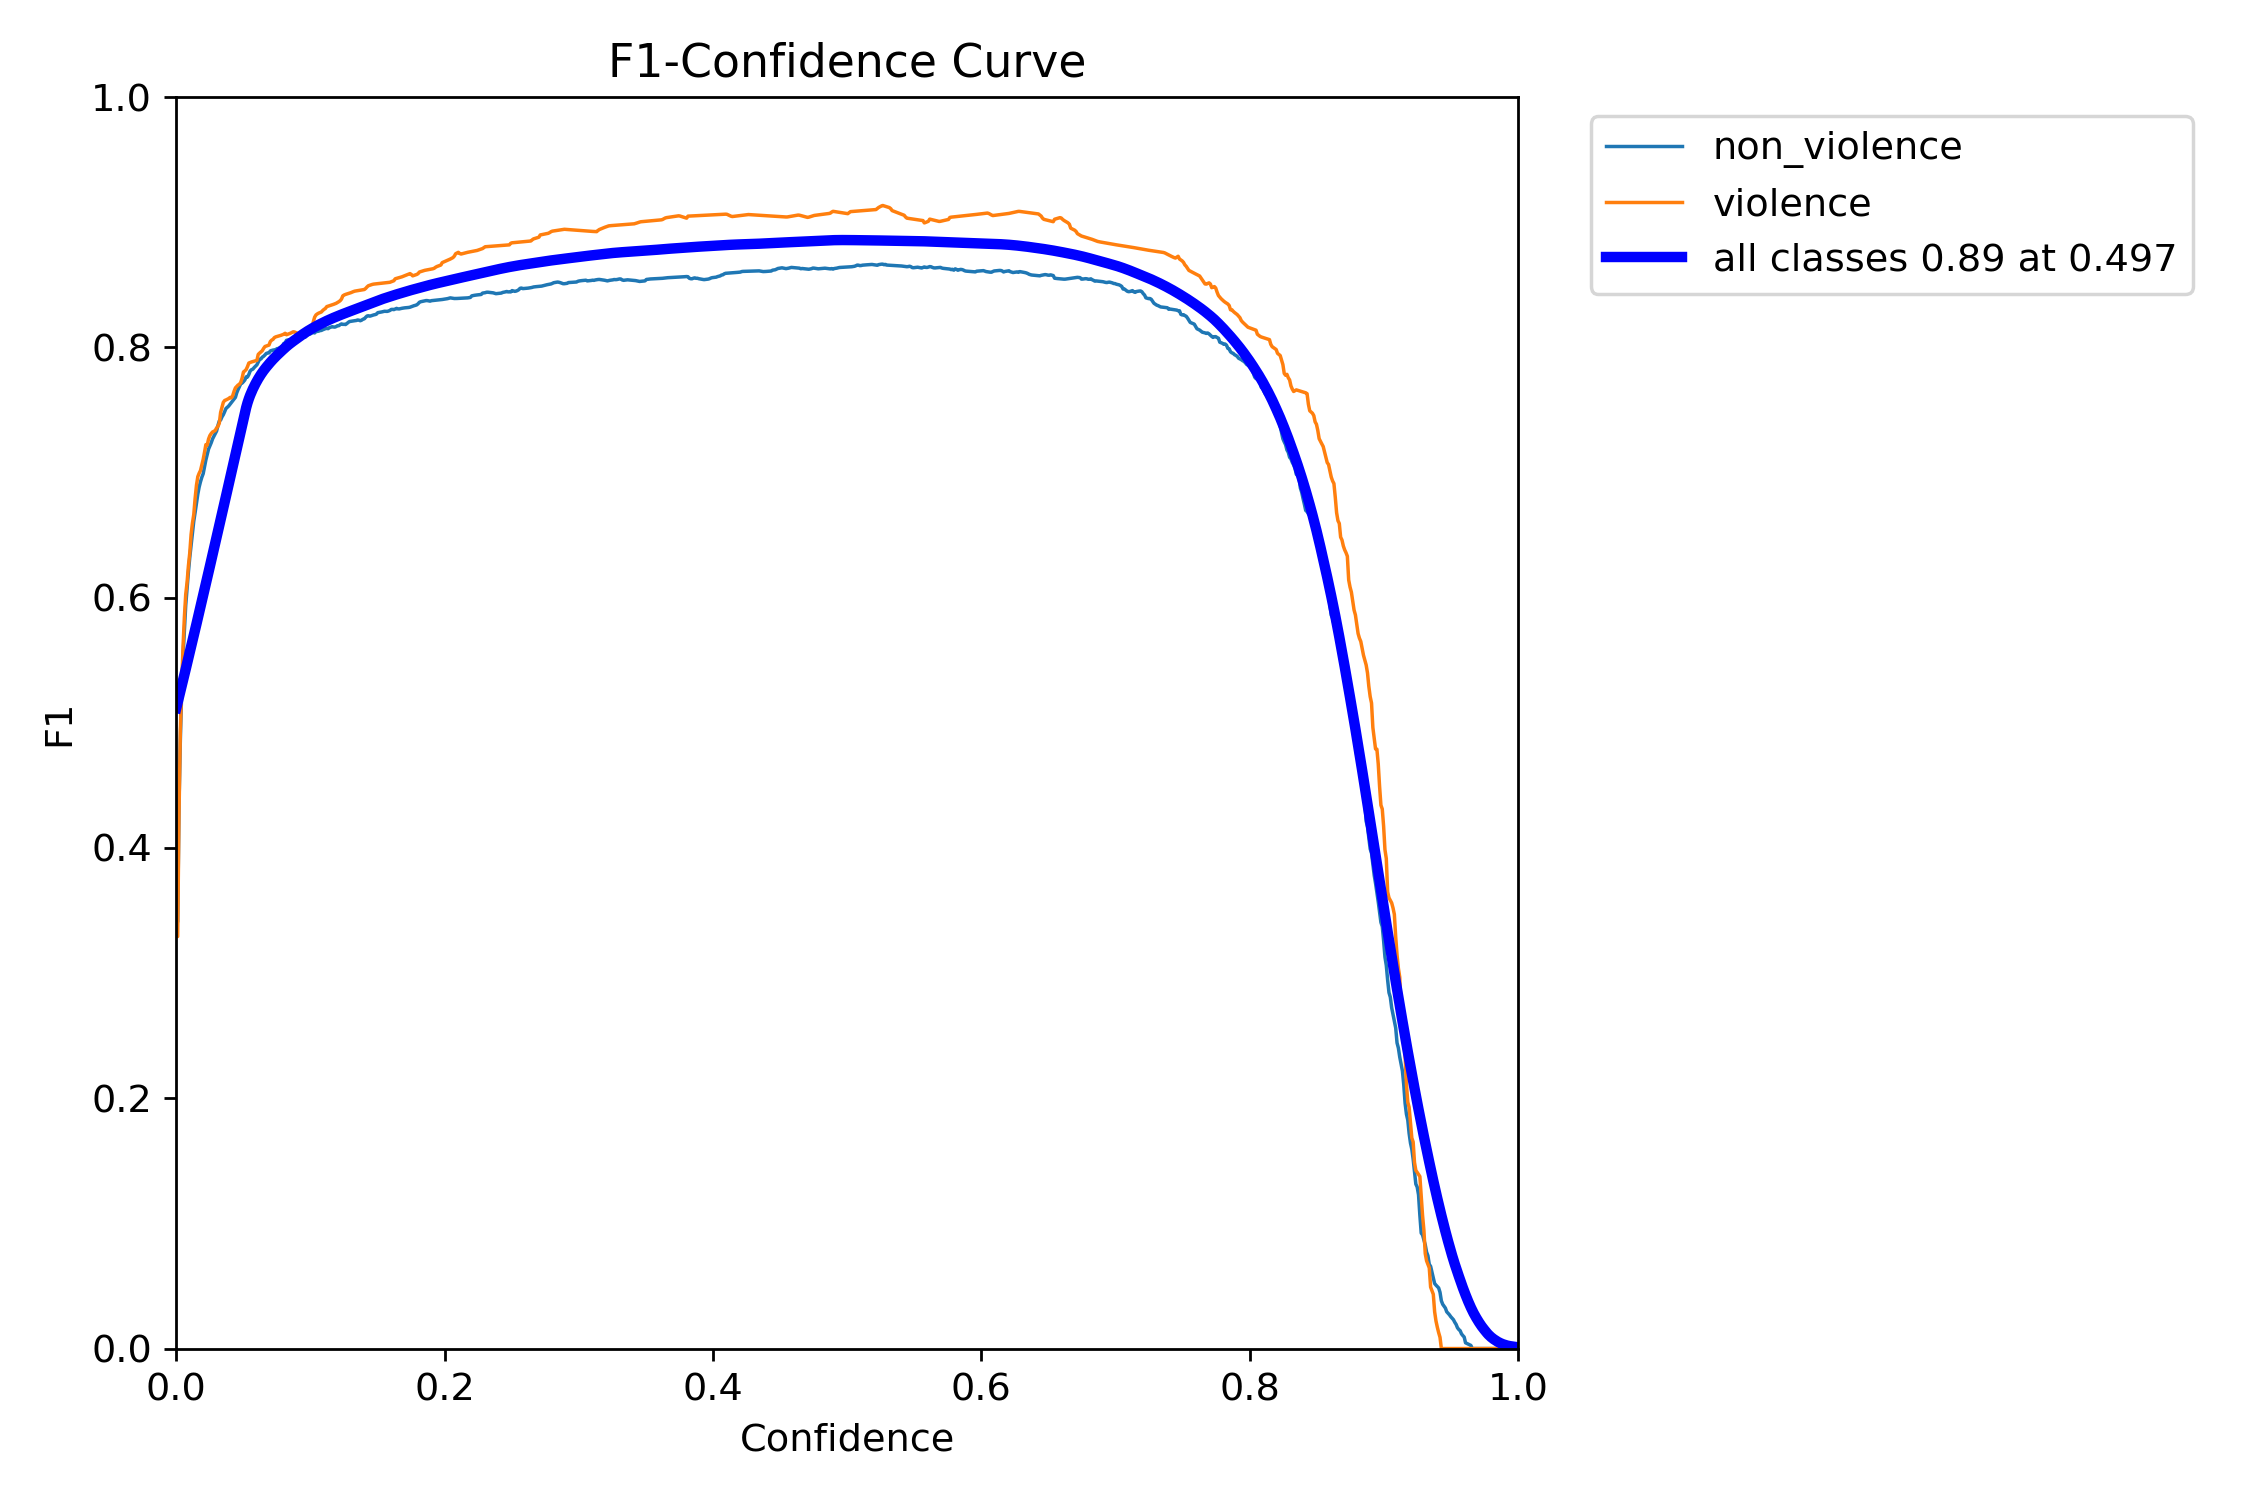

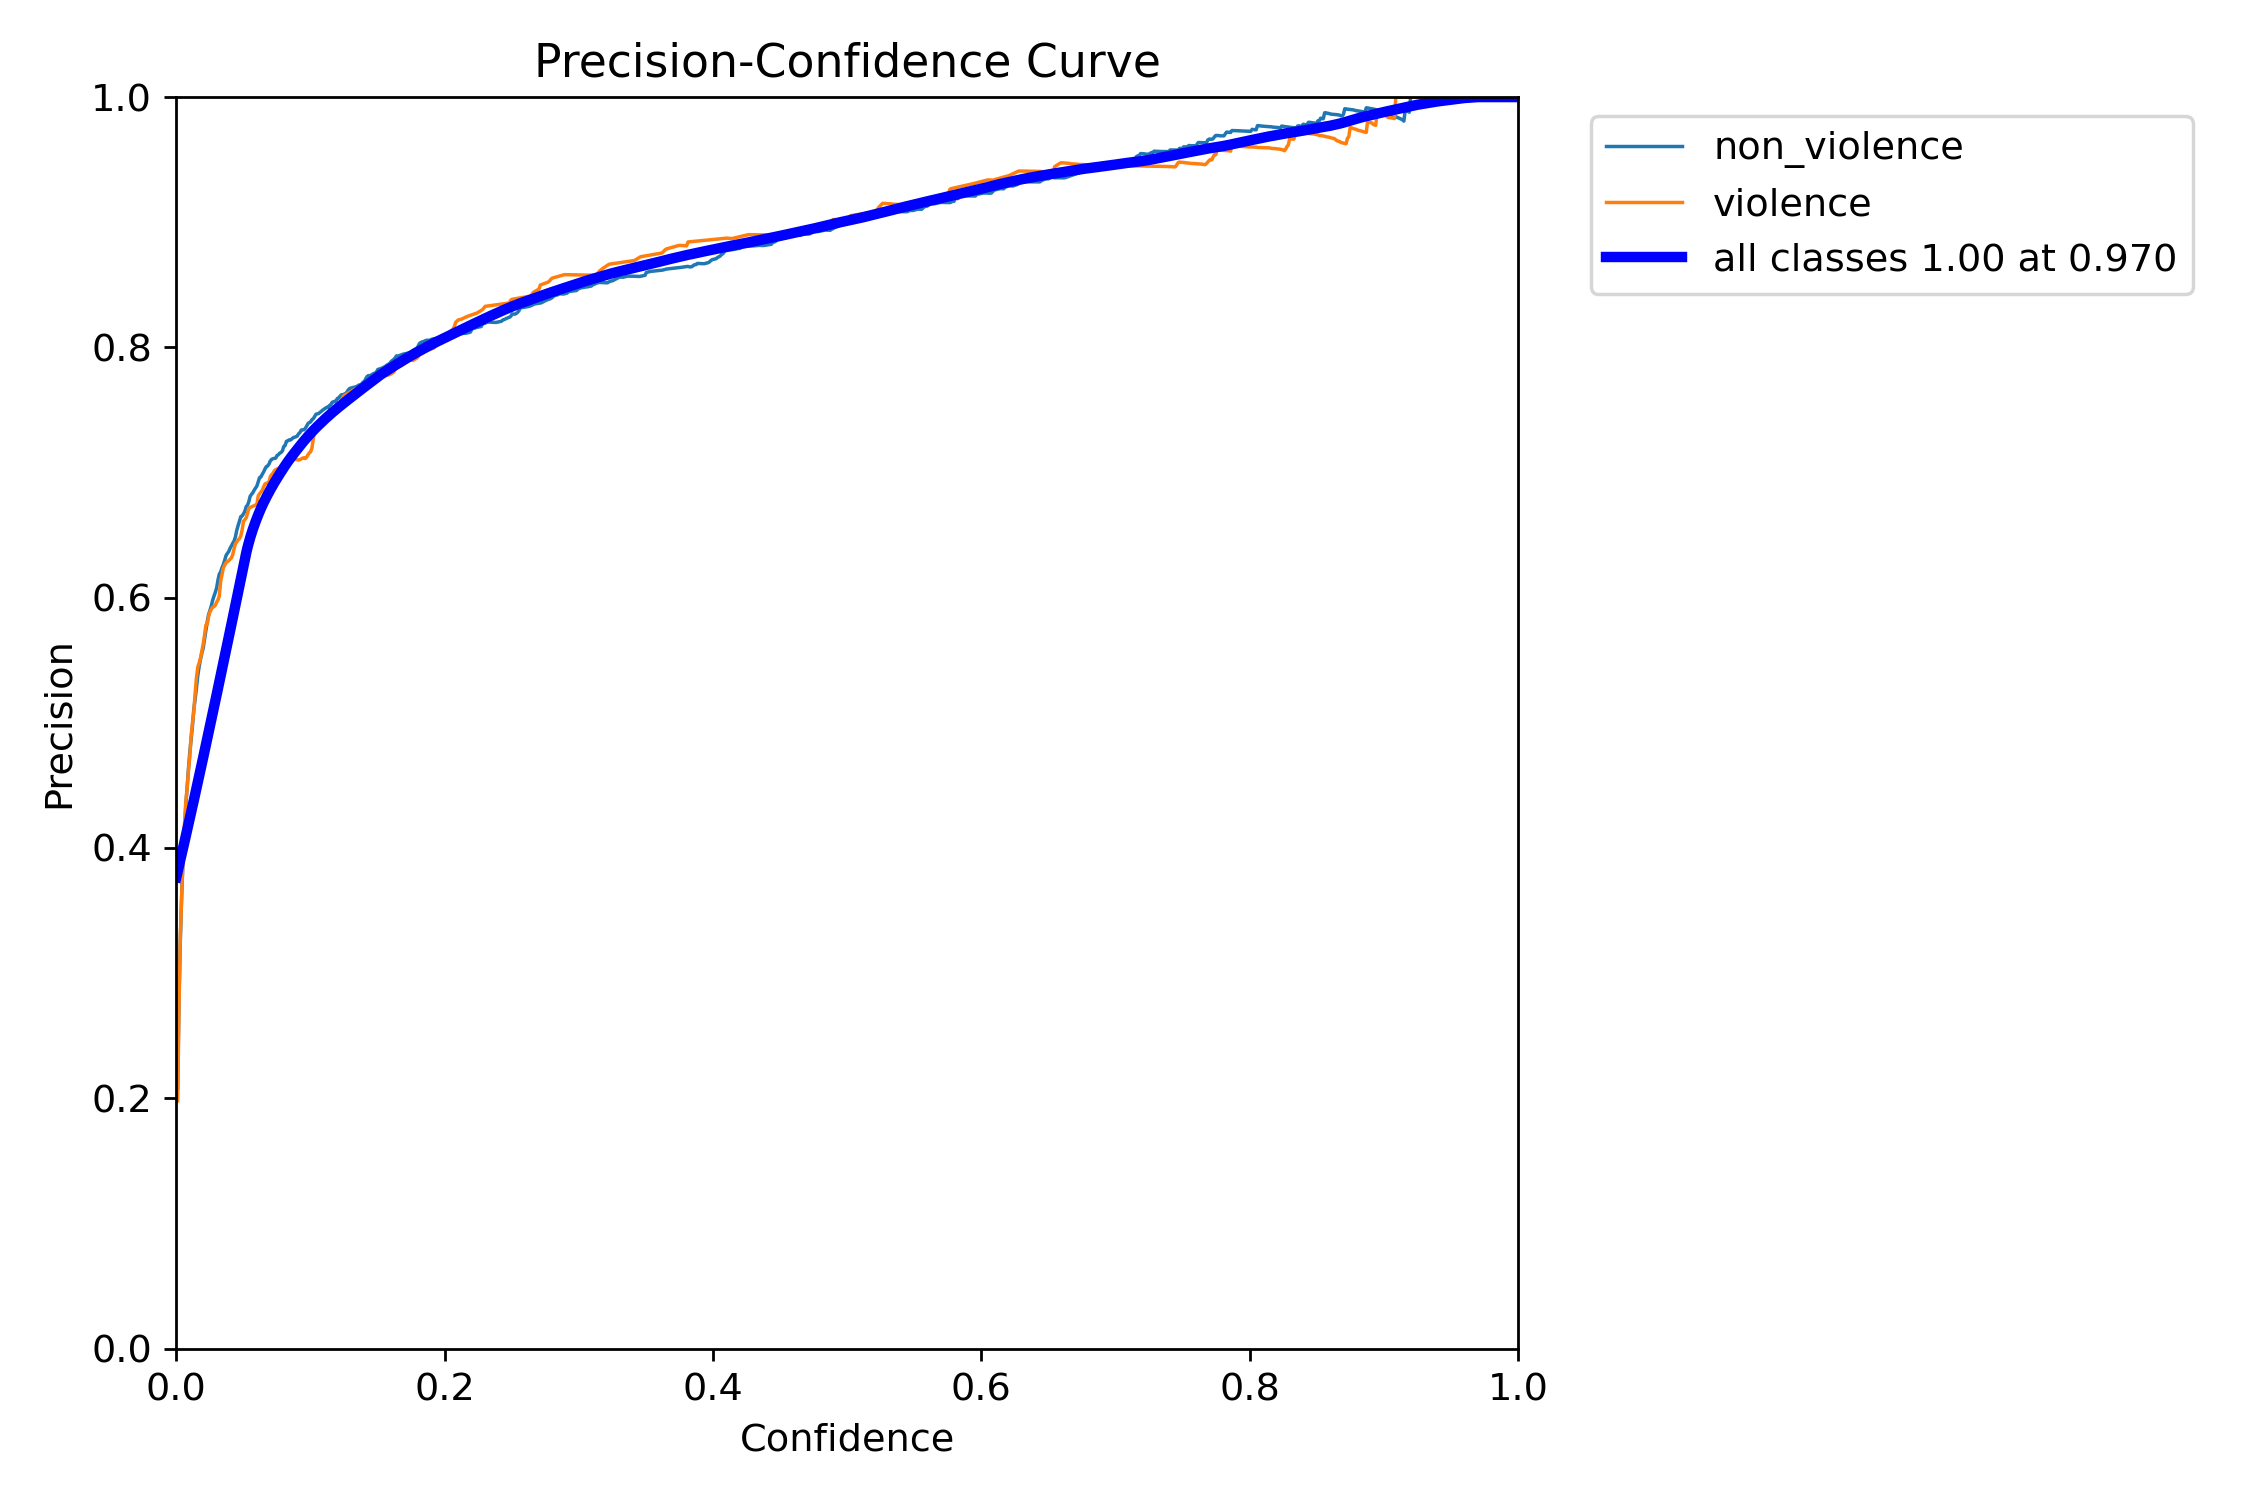

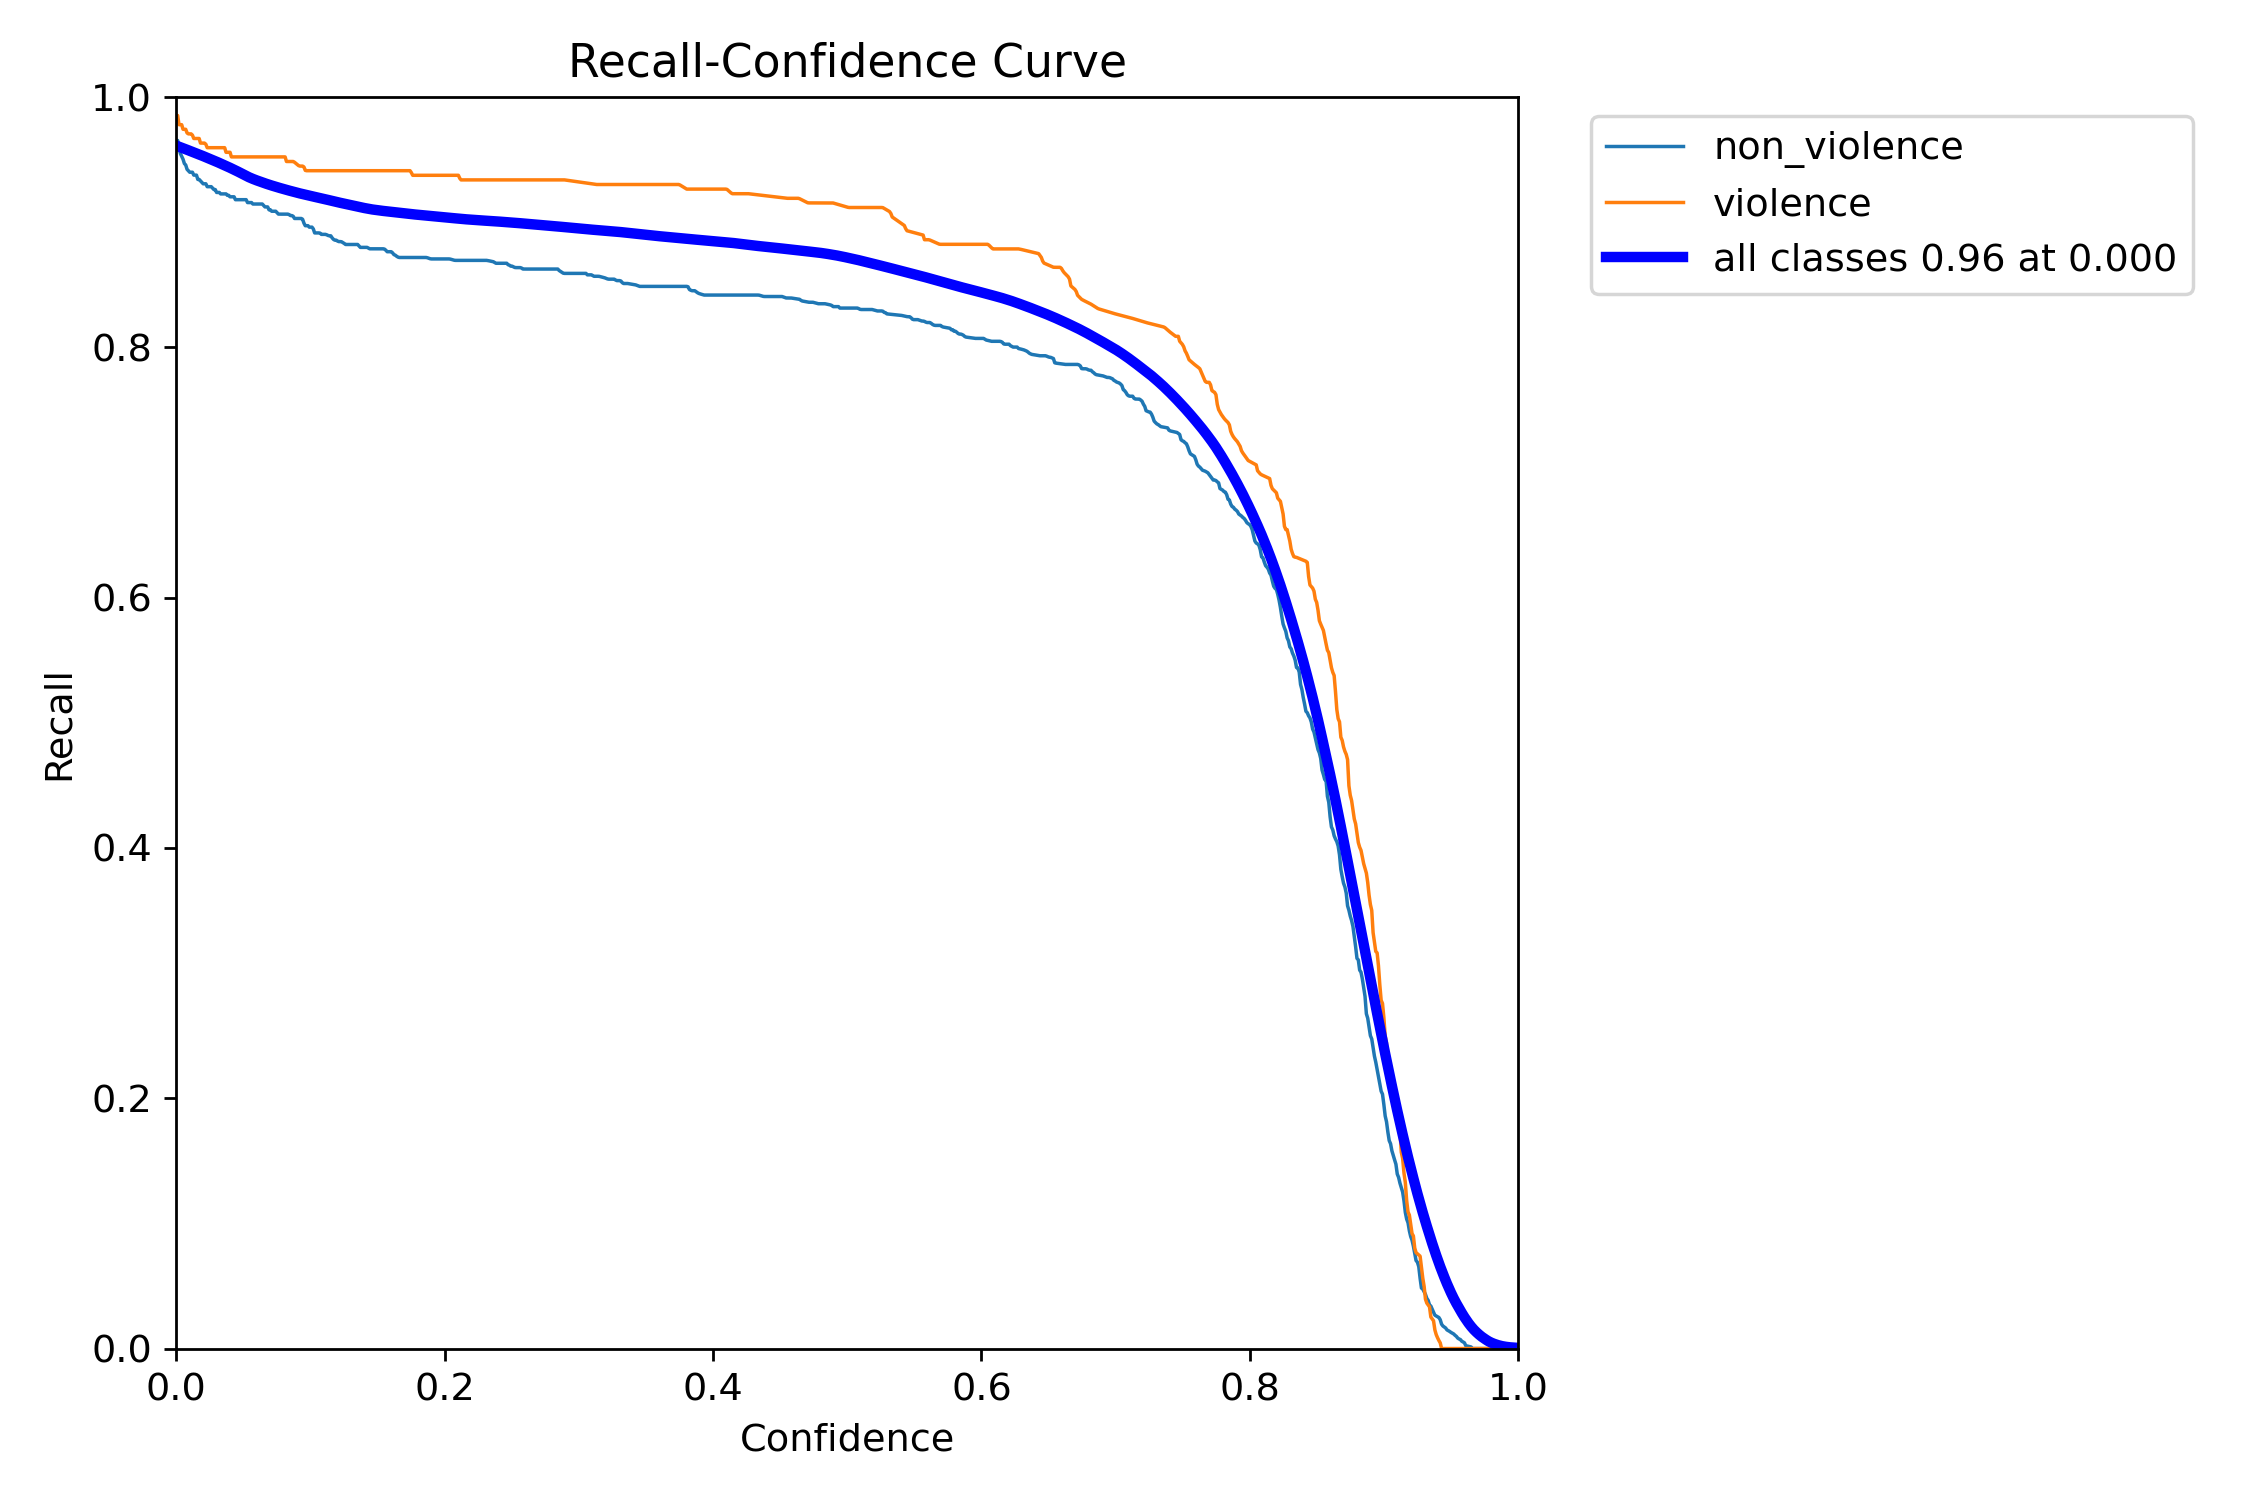

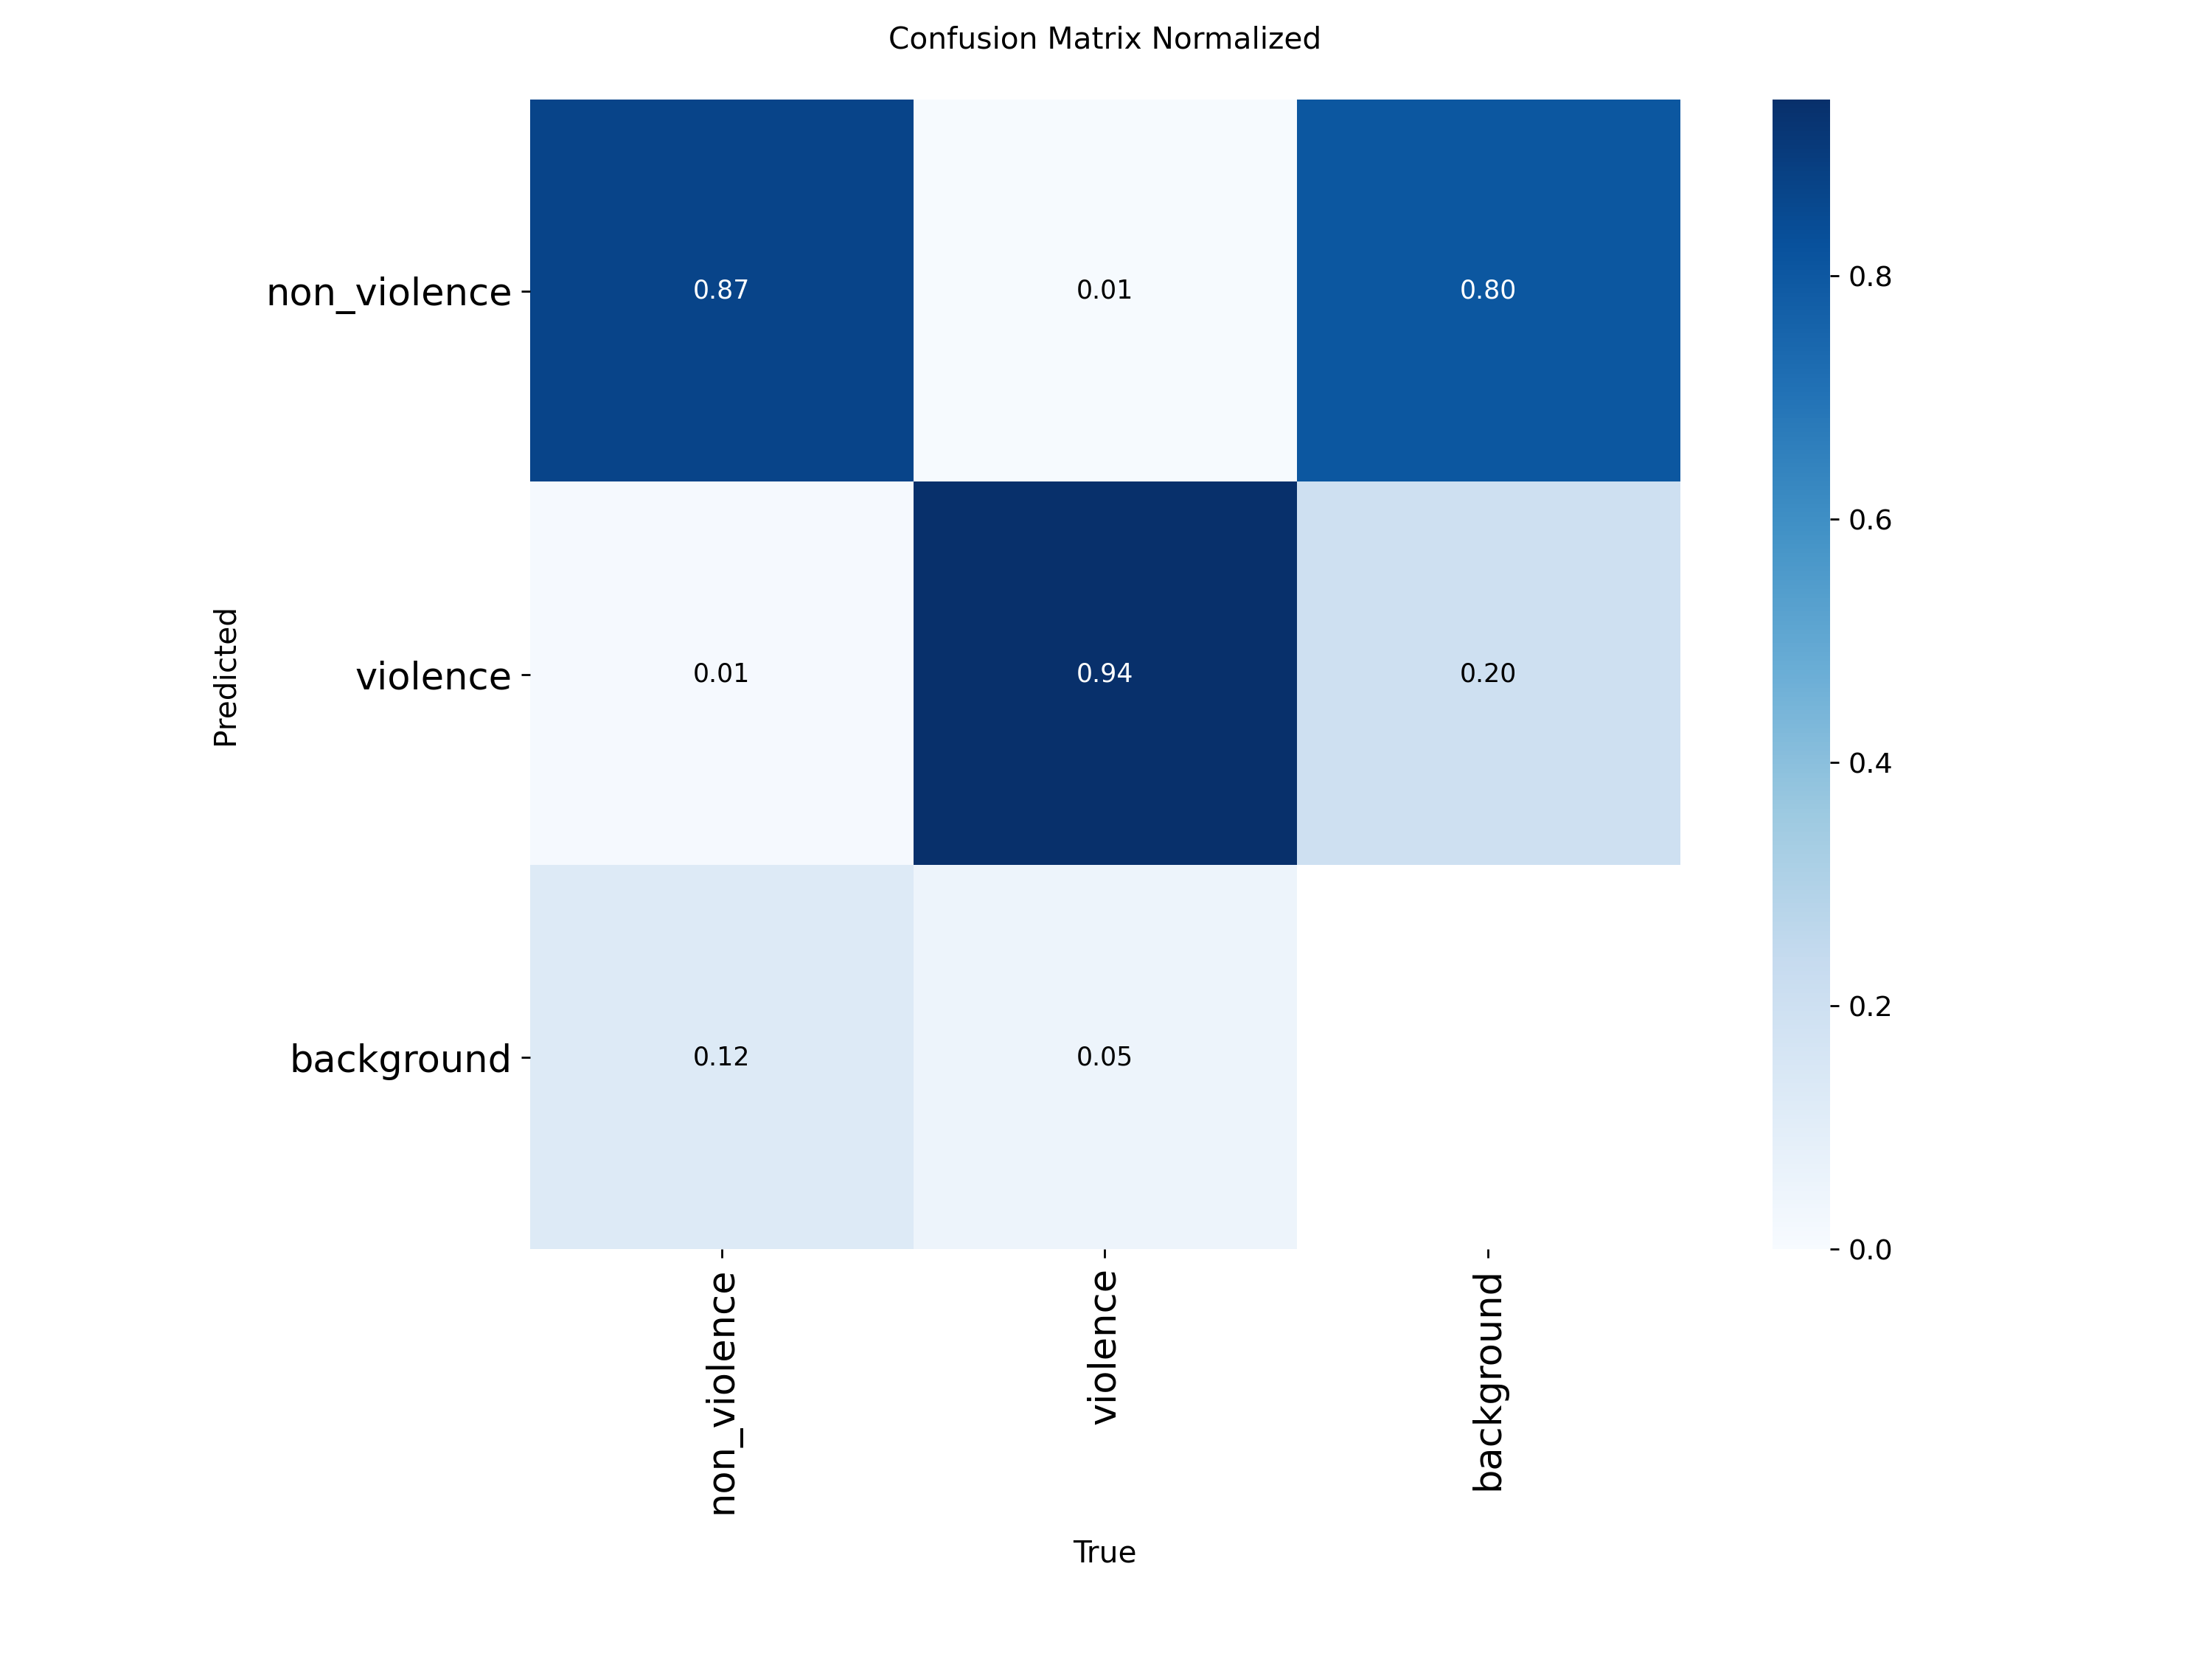

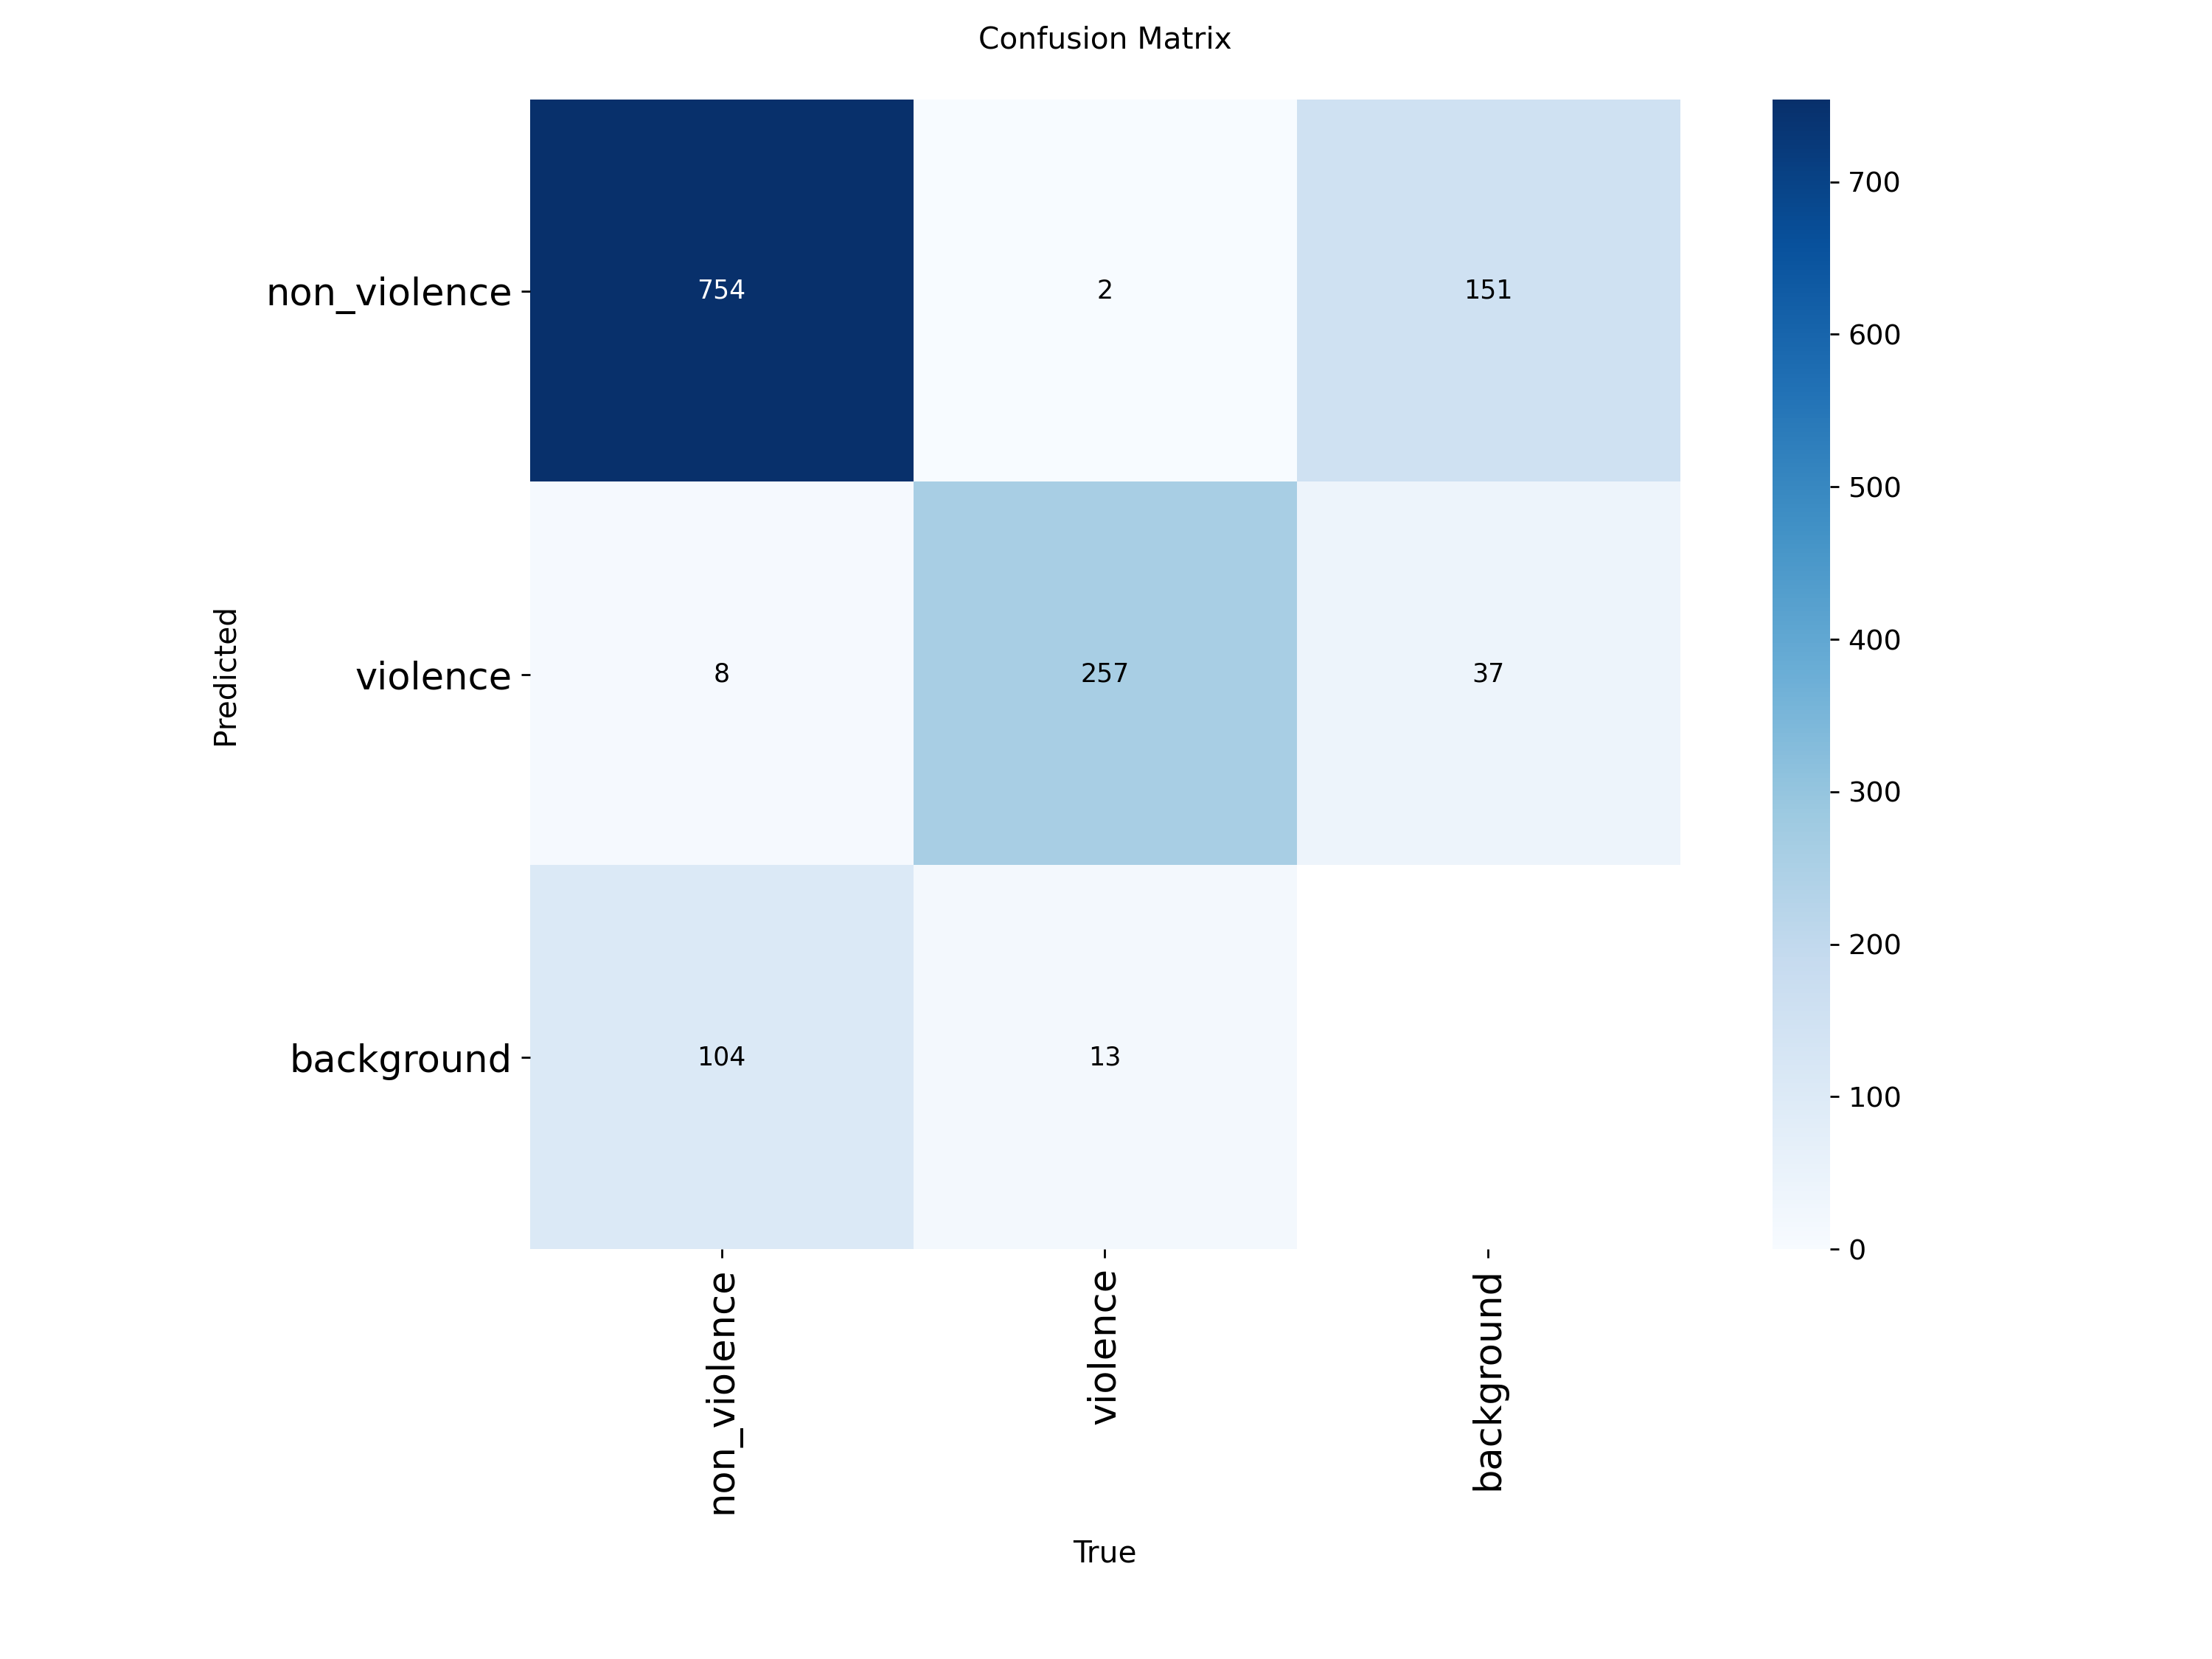

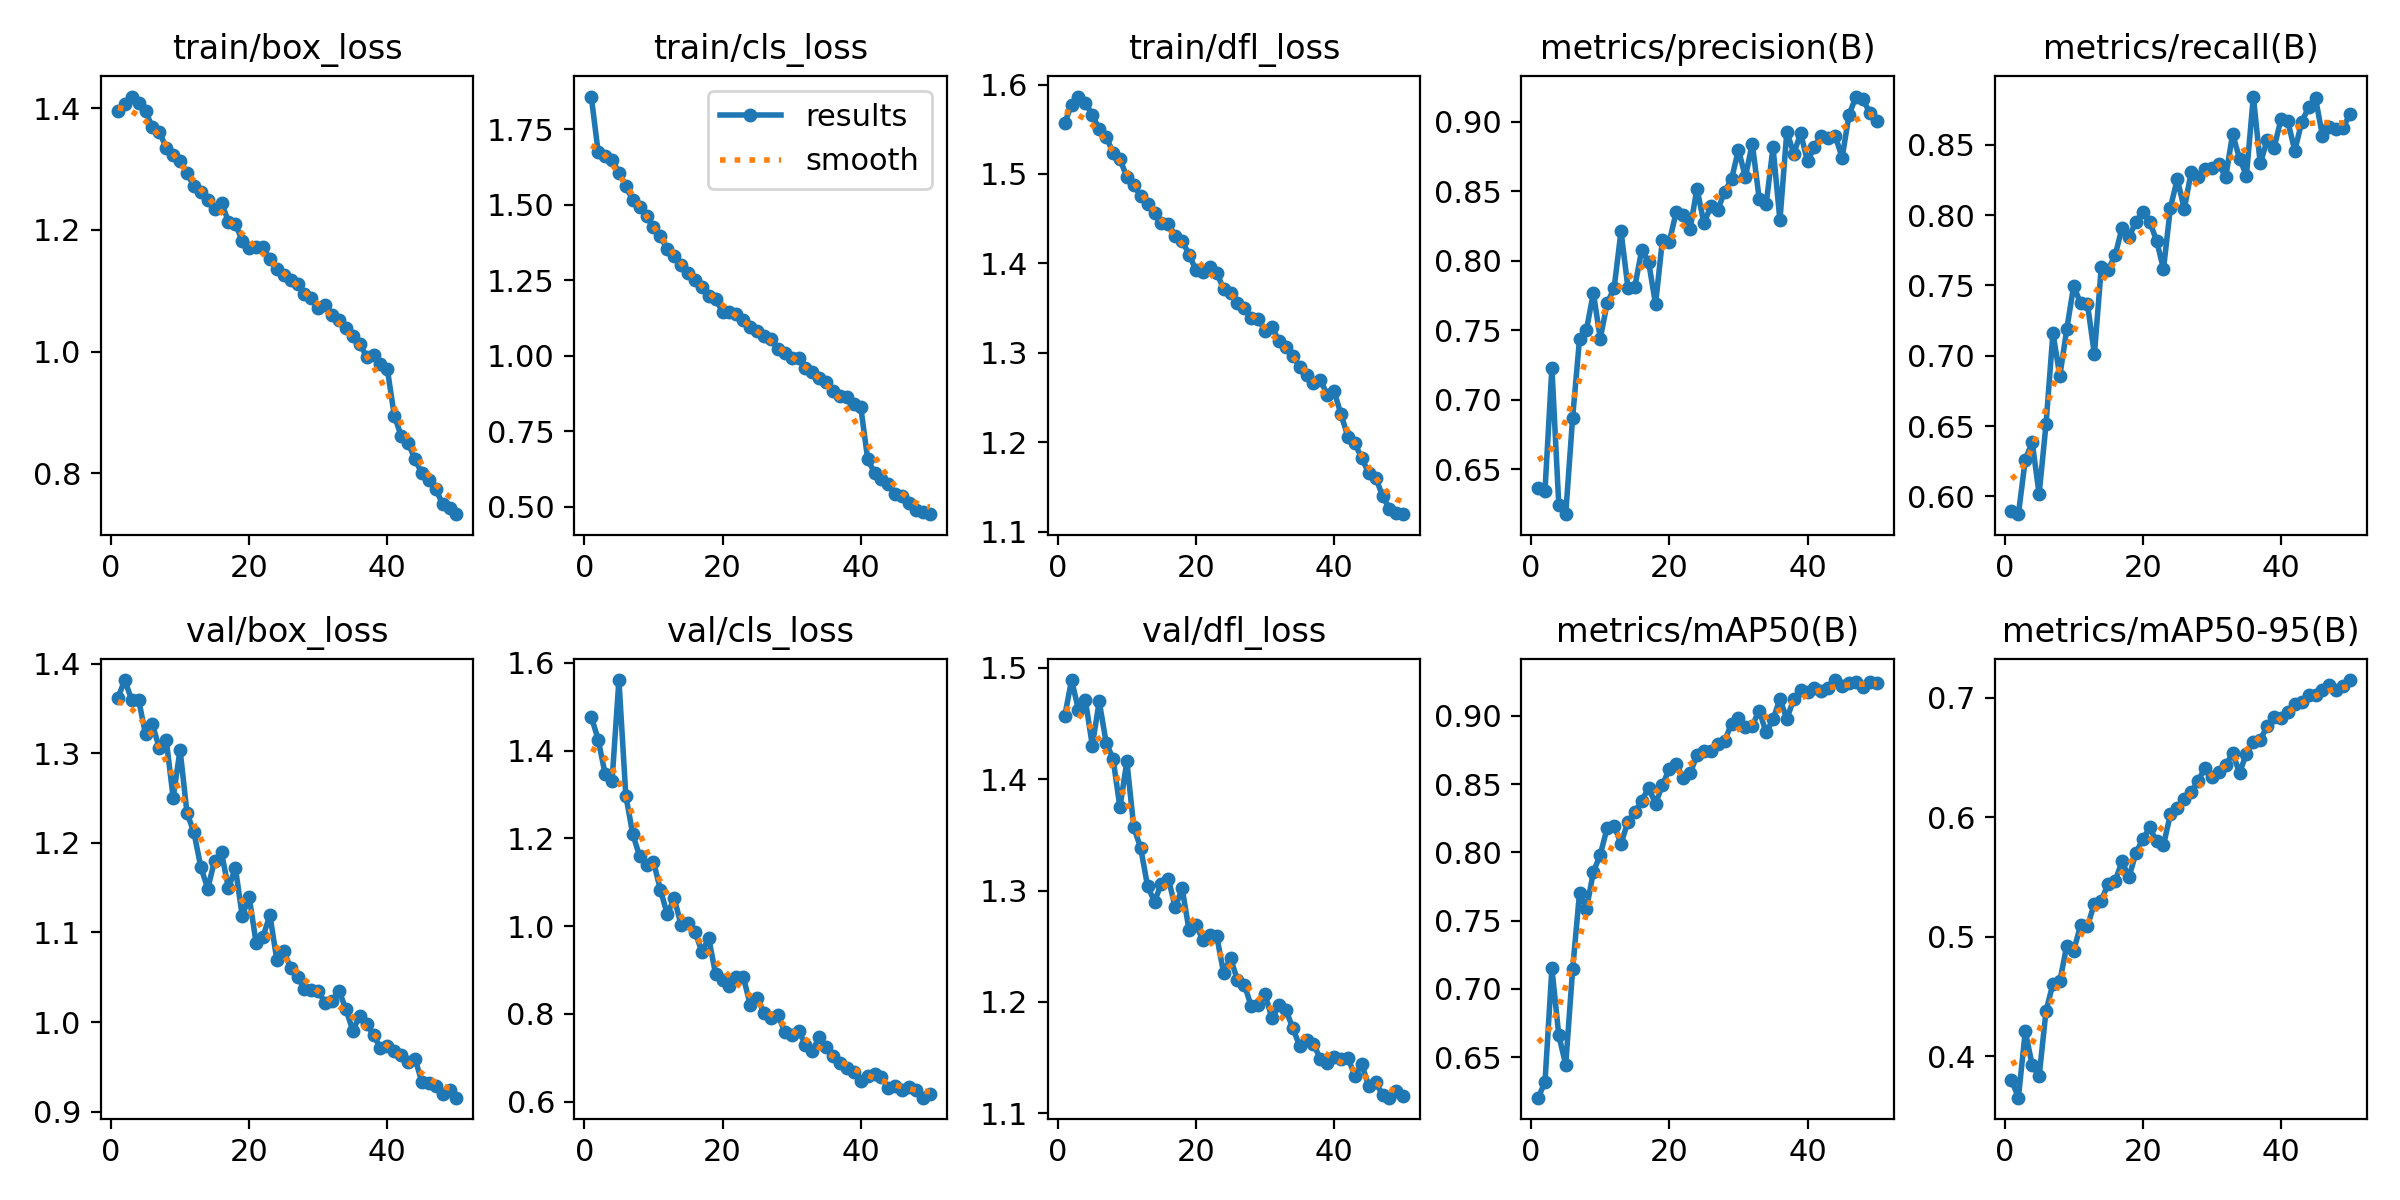

In [ ]:
from IPython.display import Image, display
for metric in glob.glob("/content/drive/MyDrive/model ml/anomaly fighting detection/FightingDetection1.4.0/runs/detect/train/*.png"):
    display(Image(filename=metric, width=800, height=500))
    print("\n")


# Inference

In [ ]:
Model = YOLO("/content/runs/detect/train/weights/best.pt")
results = Model.predict(conf=0.5, source="/content/violence-detection-4/test/images")

# Directory to save the results
save_dir = '/content/detected_images/'
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it does not exist

# Save results to the directory
for i, result in enumerate(results):
    # Generate a filename for each result
    filename = os.path.join(save_dir, f'detected_image_{i}.jpg')
    result.save(filename=filename)


image 1/468 /content/violence-detection-4/test/images/0x0_webp.rf.e08e73c05bcec1144b99ff6db9c8d8fb.jpg: 640x640 4 non_violences, 37.0ms
image 2/468 /content/violence-detection-4/test/images/861a756d129cc0ab3b468dd0ddb5fb080273e645e768afb36e735d3ca659254d-_SX1080_FMjpg__jpg.rf.461f71e5f151315bdc3540991f8f8978.jpg: 640x640 4 non_violences, 34.6ms
image 3/468 /content/violence-detection-4/test/images/Capture-d-ecran-2024-05-15-160733_png.rf.e7f858ab3c9095c3c2ecab43c74d5ba7.jpg: 640x640 2 non_violences, 33.3ms
image 4/468 /content/violence-detection-4/test/images/Capture-d-ecran-2024-05-15-161010_png.rf.ab1803761e1f41e98f5f244e872f9d38.jpg: 640x640 1 violence, 33.3ms
image 5/468 /content/violence-detection-4/test/images/Capture-d-ecran-2024-05-15-161524_png.rf.f77965f4781442e85b6bb4cceadf65a5.jpg: 640x640 1 non_violence, 33.4ms
image 6/468 /content/violence-detection-4/test/images/Capture-d-ecran-2024-05-15-162508_png.rf.6c6b61a9ce269074f1b769e600872873.jpg: 640x640 2 non_violences, 33.3m

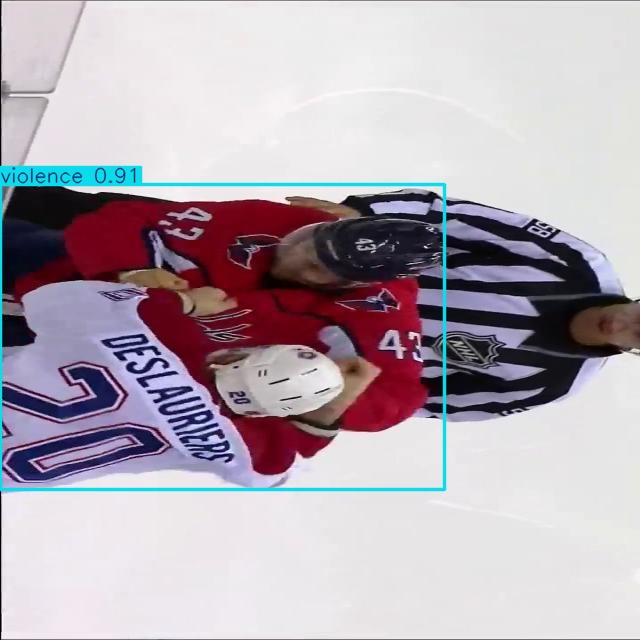

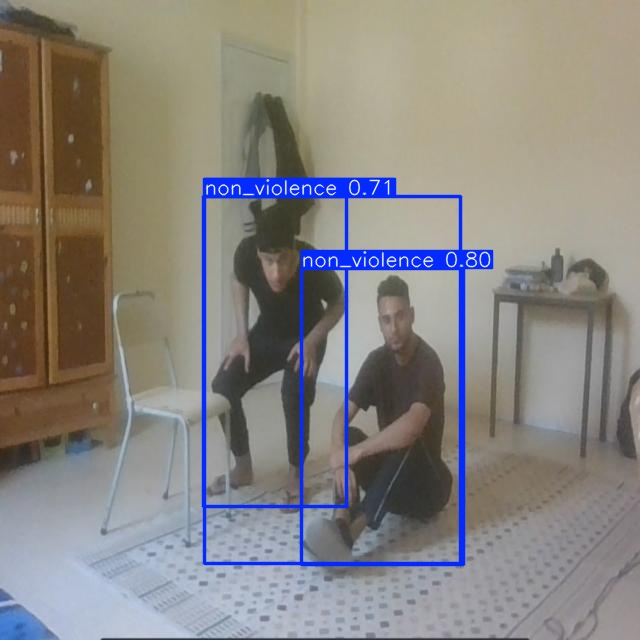

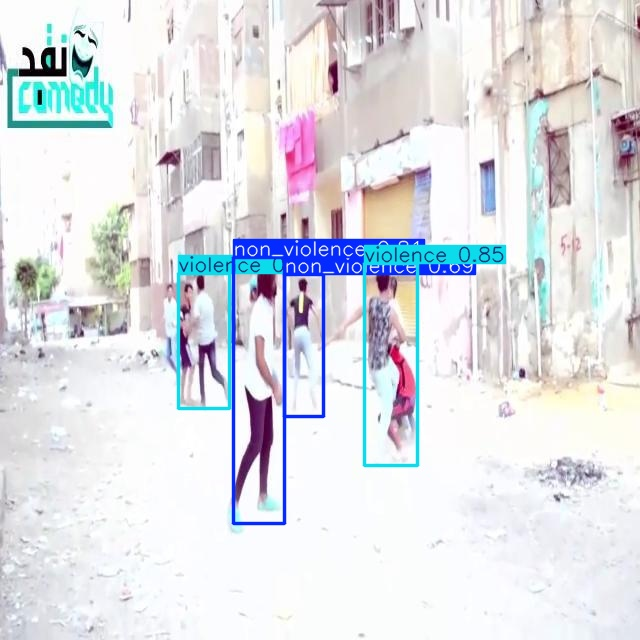

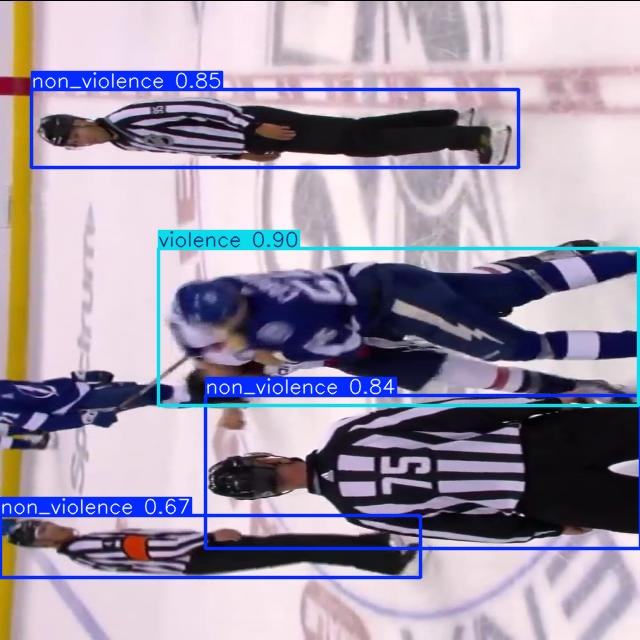

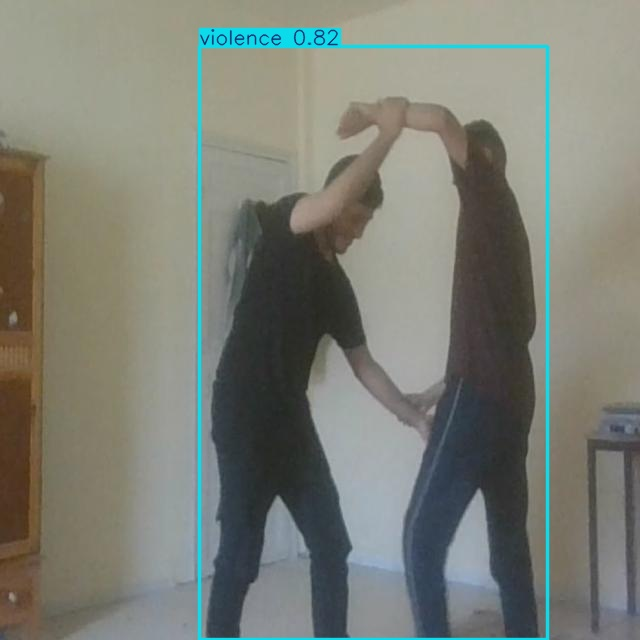

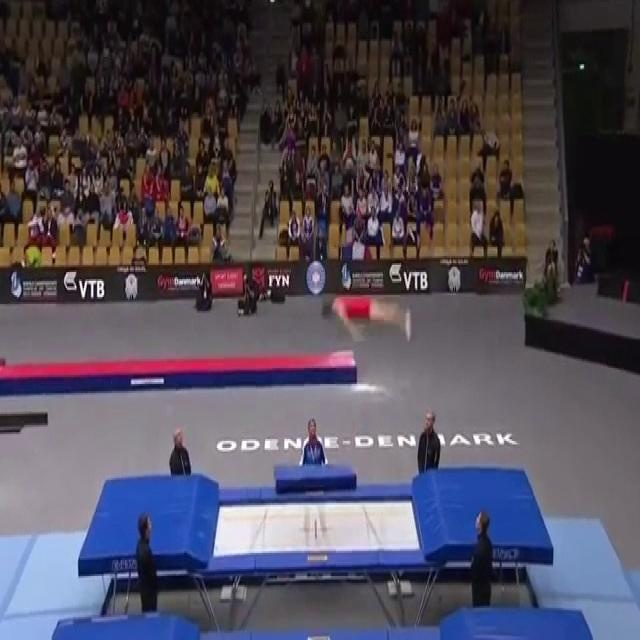

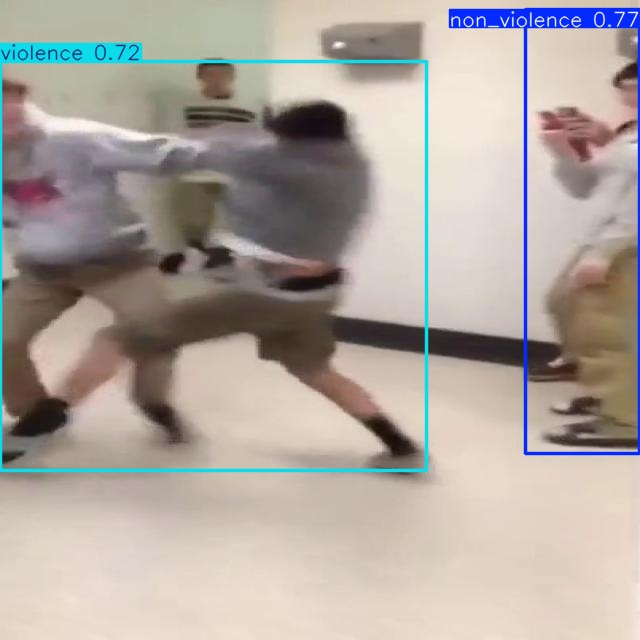

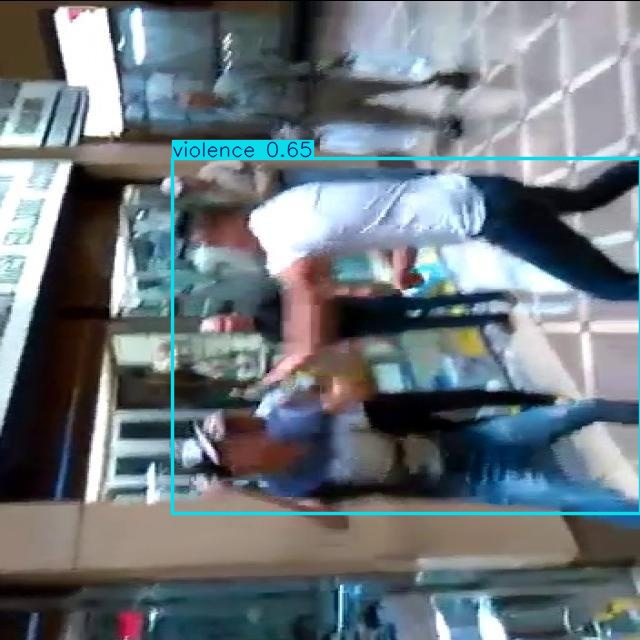

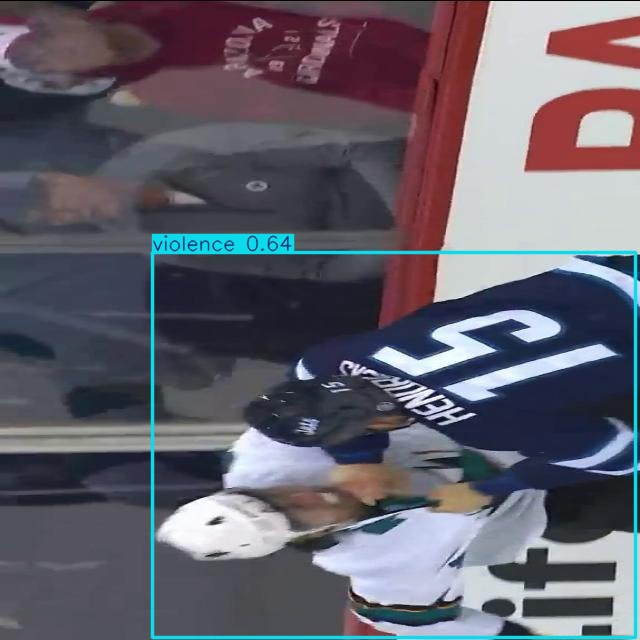

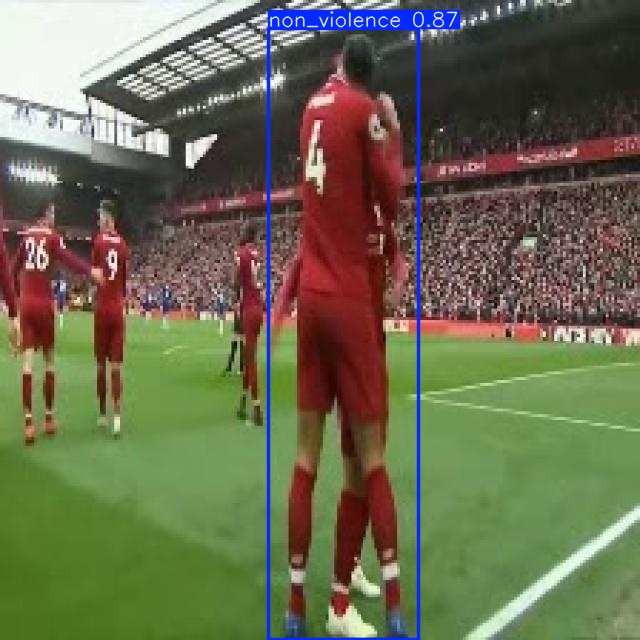

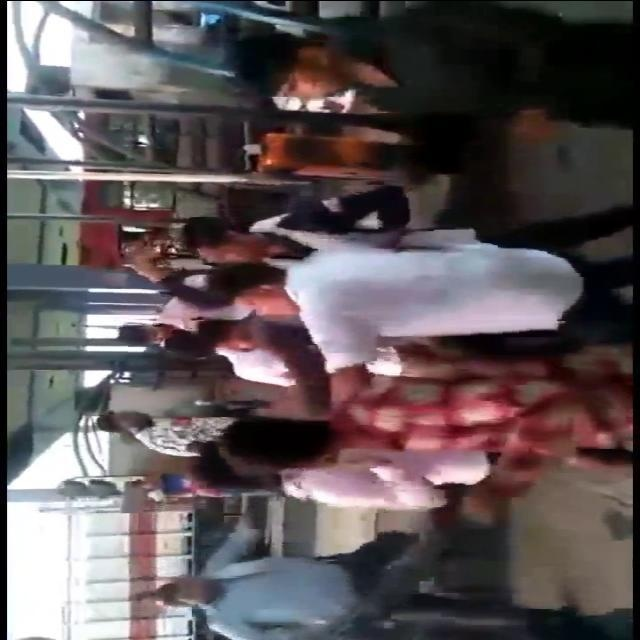

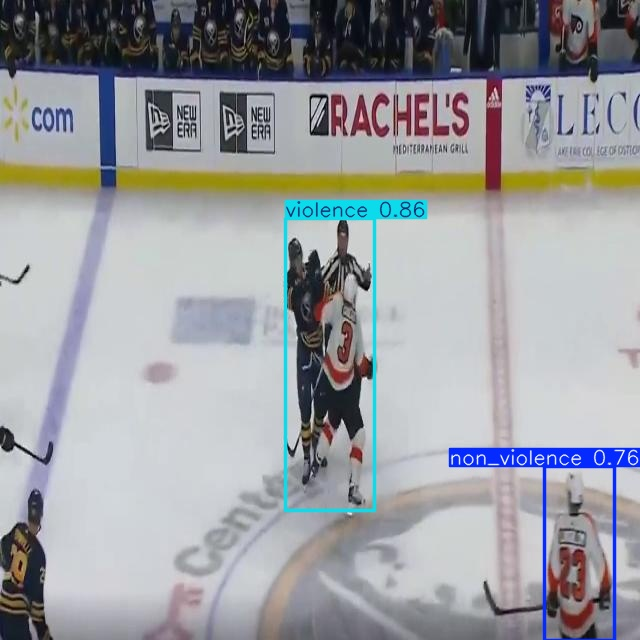

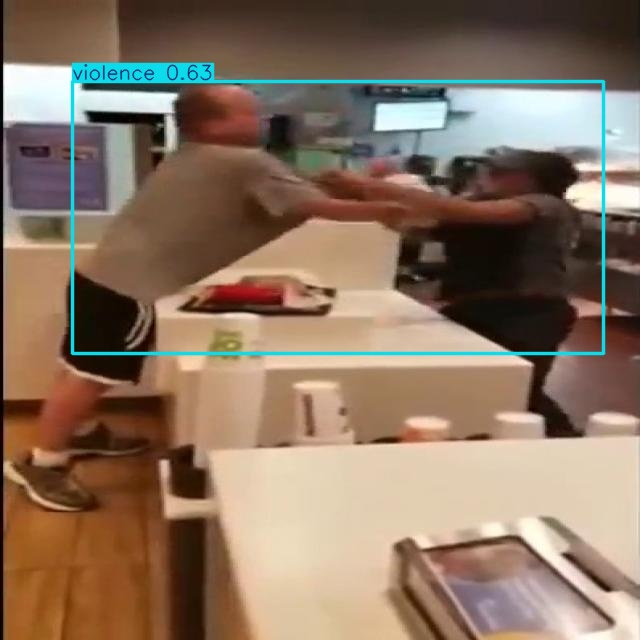

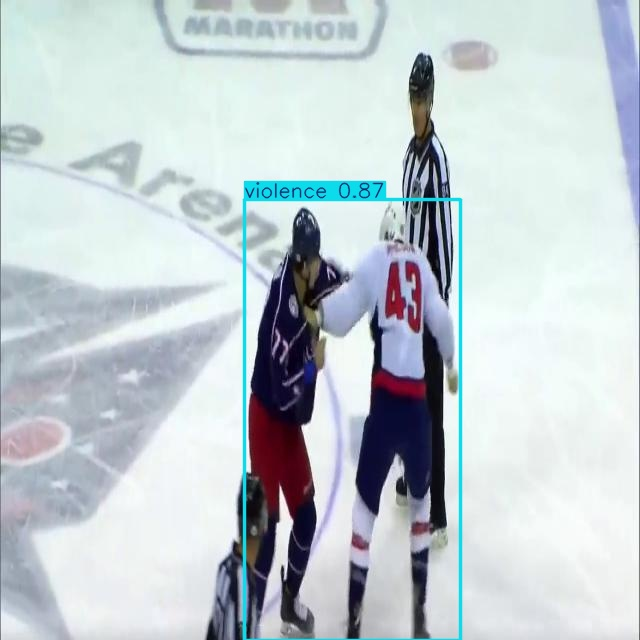

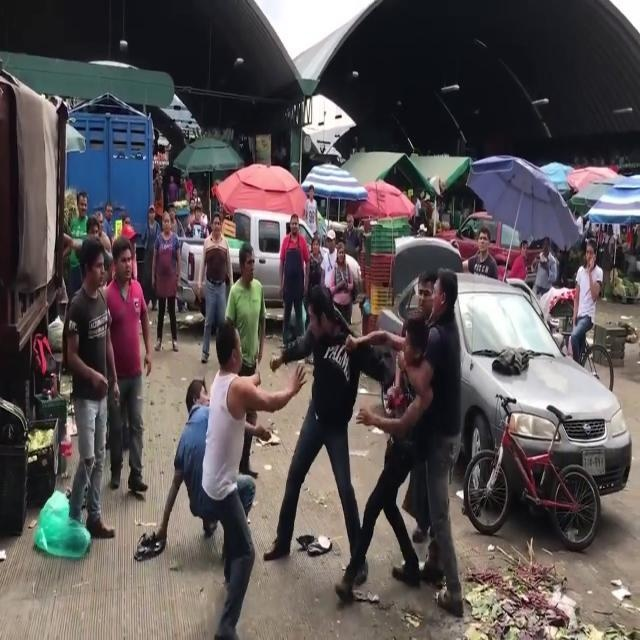

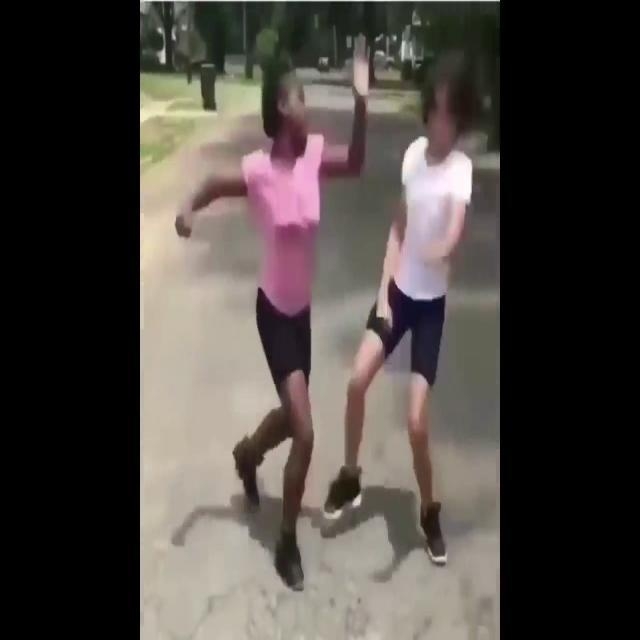

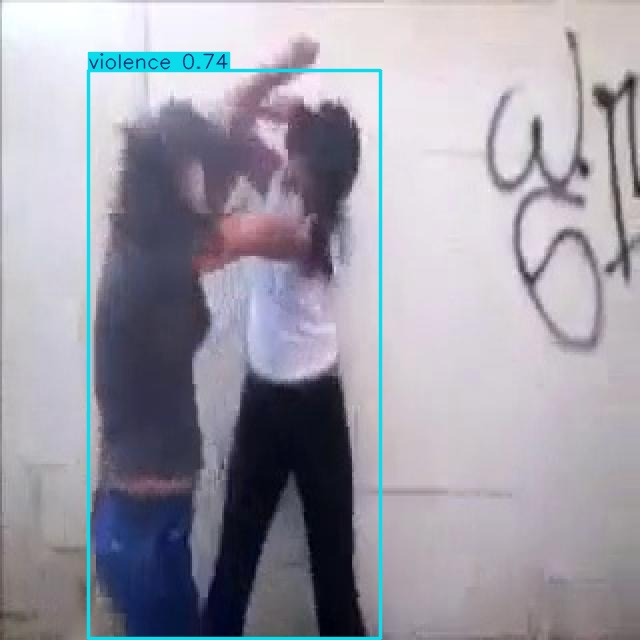

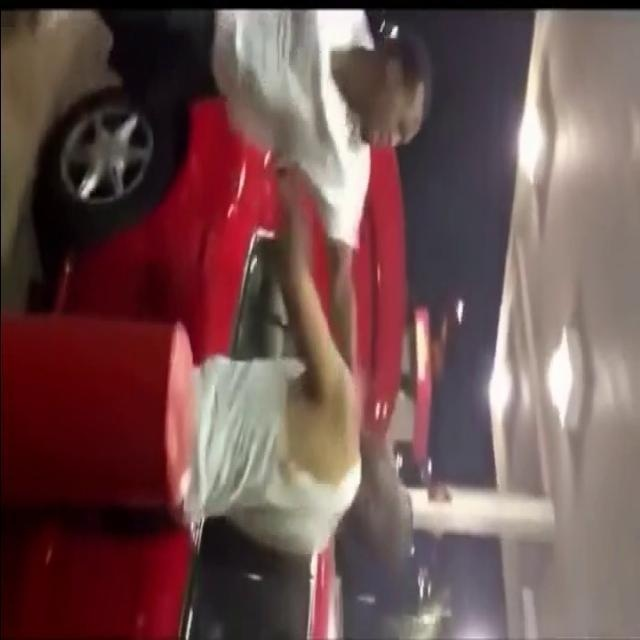

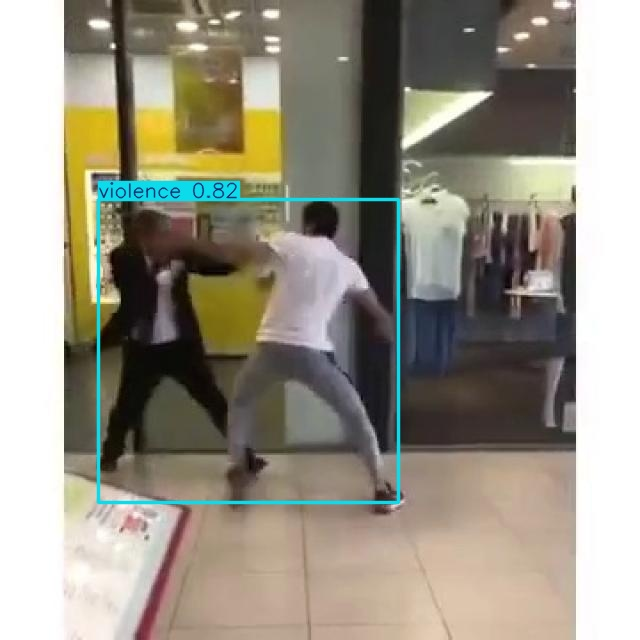

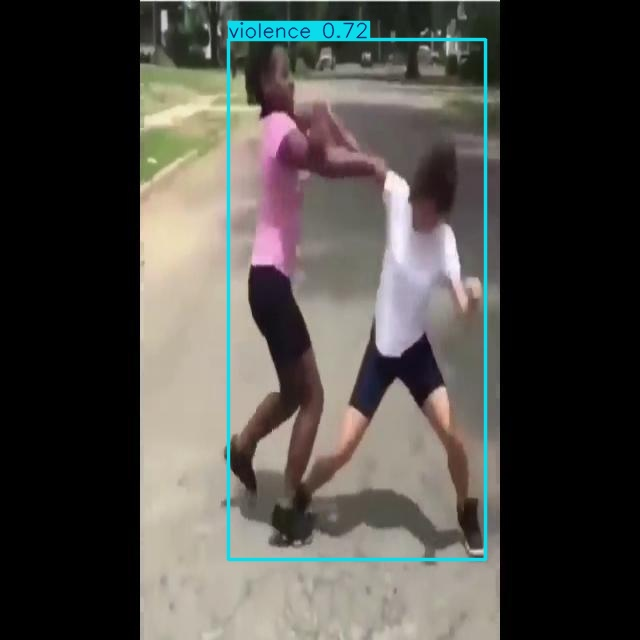

In [ ]:
i = 20
for image in glob.glob("/content/detected_images/*.jpg"):
    display(Image(filename=image, width=800, height=500))
    i-=1
    if i ==0:
        break